['S3', 'S4']
[8, 10]
[['R0', 'S0', 'S4'], ['R0', 'S1', 'S4'], ['R0', 'S2', 'S4']]
3
['R0+S0s -> R0+S0', 'R0+S1s -> R0+S1', 'R0+S2s -> R0+S2', 'S0+S3s -> S0+S3', 'S0+S4s -> S0+S4', 'S1+S3s -> S1+S3', 'S1+S4s -> S1+S4', 'S2+S3s -> S2+S3', 'S2+S4s -> S2+S4', 'S0s -> S0', 'S1s -> S1', 'S2s -> S2', 'S3s -> S3', 'S4s -> S4']
[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1.]]
['R0+S0s -> R0+S0', 'R0+S1s -> R0+S1', 'R0+S2s -> R0+S2', 'S0+S3s -> S0+S3', 'S0+S4s -> S0+S4', 'S1+S3s -> S1+S3', 'S1+S4s -> S1+S4', 'S2+S3s -> S2+S3', 'S2+S4s -> S2+S4', 'S0s -> S0', 'S1s -> S1', 'S2s -> S2', 'S3s -> S3', 'S4s -> S4']
Complexes per class: [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
Reactions per class: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Extra conservations 0
Linkage group 1: {'R0+S0': 'R0+S0', 'R0+S0s': 'R0+S0s'}
Linkage group 2: {'

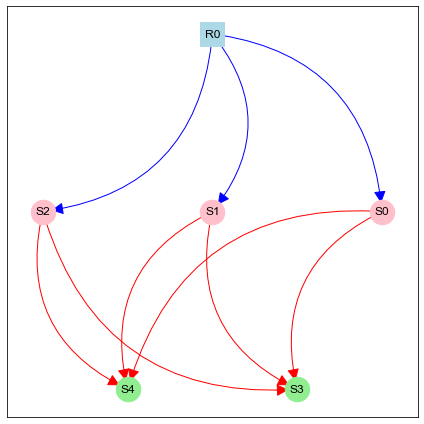

In [1]:
from CRNs import *
import numpy as np
import matplotlib.pyplot as plt
import sympy
import networkx as nx
import random
from sympy import Poly, Symbol

from scipy.integrate import solve_ivp
from functools import partial
import time

# --- Example usage with new class structure ---
seed = 52
np.random.seed(seed)
random.seed(seed)

NR = 1

NS_vec = [3,2]
NS = sum(NS_vec)
p_f = 0.75
p_r = 0

target_nodes = [f'S{NS-2}', f'S{NS-1}']
print(target_nodes)

# species_names, reaction_strings, L, input_indices = generate_random_signaling_network(NR, NL, NL_in, prob, include_reverse=True, include_uncatalyzed=True)

#species_names, reaction_strings, L, adjacency_matrix, input_substrates = generate_dag_signaling_network(NR, NS, p_f, p_r, include_reverse=True, include_uncatalyzed=True)
species_names, reaction_strings, L, adjacency_matrix, input_substrates_list = generate_layered_feedforward_signaling_network(NR, NS_vec, p_r, include_reverse=False, include_uncatalyzed=True)

target_node_idxs = [species_names.index(node) for node in target_nodes]
print(target_node_idxs)
visualize_dag_signaling_network(adjacency_matrix, input_substrates_list, NR, NS, num_outs=NS_vec[-1])
G = get_digraph_from_adjacency_matrix(adjacency_matrix, input_substrates_list, NR, NS)
n_paths = count_simple_paths(G, f'R0', f'S{NS-1}')
print(n_paths)
print(len(n_paths))
#print(input_indices)
print(reaction_strings)

# n_nodes = 3
# NS = 1
# prob = 1
# extra_reactions = ['A+B -> C+C']
# input_reactions_list = [['R0+A -> R0+B']]
# species_names, reaction_strings, L = generate_random_first_order_network(n_nodes, input_reactions_list, prob, extra_reactions = extra_reactions, include_reverse=False)
# #visualize_dag_signaling_network(adjacency_matrix, input_substrates, NR, NS)

print(L)
print(reaction_strings)

# NR = 1
# NL_vec = [2,2]
# species_names, reaction_strings, L = generate_feedforward_signaling_network(NR, NL_vec)

r_n = ReactionNetwork.from_reaction_strings(
    reaction_strings=reaction_strings,
    L=L,
    seed=42,
    species_names=species_names,
    force_reverse=True
)

# 1. Create the simulator
sim = ReactionNetworkSimulator(r_n)

print("Complexes per class:", r_n.complexes_per_class)
print("Reactions per class:", r_n.reactions_per_class)
print("Extra conservations", r_n.n_species - np.linalg.matrix_rank(r_n.Y @ r_n.A) - r_n.n_cons)

for i, node_assignment in enumerate(r_n.assignments):
    print(f"Linkage group {i+1}: {node_assignment}")

# symbolic ODEs
symbolic_rhs, species, rates = sim.get_symbolic_rhs()
reduced_rhs, remaining_syms, const_syms, rate_syms = sim.get_symbolic_reduced_rhs()
dR_dC, dR_dC_func, dR_dl, dR_dl_func, dR_dk, dR_dk_func, remaining_syms = sim.get_first_order_derivatives()


cycles = compute_cycles(r_n)

# # Visualize linkage classes
# sz = 3
# fig, axes = plt.subplots(1, len(r_n.linkage_groups), figsize=(sz*len(r_n.linkage_groups), sz))

# if len(r_n.linkage_groups) == 1:
#     pos = nx.spring_layout(r_n.linkage_groups[0])
#     nx.draw(r_n.linkage_groups[0], pos=pos, with_labels=True, ax=axes, node_size=1000, connectionstyle='arc3,rad=0.2', arrows=True)
#     axes.set_title("Linkage class 1")
# else:
#     for i, (G, ax) in enumerate(zip(r_n.linkage_groups, axes)):
#         pos = nx.spring_layout(G)
#         nx.draw(G, pos=pos, with_labels=True, ax=ax, node_size=1000, connectionstyle='arc3,rad=0.2', arrows=True)
#         ax.set_title(f"Linkage class {i+1}")
# plt.tight_layout()
# plt.show()

# 2. Reduce the ODE system using conservation laws
sim.solve_conservation_laws()
print("Remaining species after reduction:", sim.remaining_species)
print("Conservation constants (symbols):", sim.const_syms)
print("Eliminated species solutions:", sim.elimination_solutions)



rates_orig = np.array([r_n.reactions[r_idx][2] for r_idx in range(len(r_n.reactions))])


In [ ]:
# print(r_n.get_rates())
# print(r_n.reactions)
# print(r_n.species_names)
# print(r_n.all_complexes)
# print(r_n.get_reaction_strings())
# print(G.nodes)
# print(G.edges)



class GraphComputation:
    """Computational graph for reaction networks using NumPy."""
    
    def __init__(self, G, input_nodes, output_nodes):
        self.G = G
        self.input_nodes = input_nodes
        self.output_nodes = output_nodes
        self.topo_order = list(nx.topological_sort(G))
        self.edges = list(G.edges)
        self.nodes = list(G.nodes)
        self.n_nodes = len(self.nodes)
        self.n_edges = len(self.edges)
        
        # Create node index mappings
        self.node_to_idx = {n: i for i, n in enumerate(self.nodes)}
        self.edge_to_idx = {e: i for i, e in enumerate(self.edges)}
        
        # Pre-compute indices for fast access
        self.input_idxs = np.array([self.node_to_idx[n] for n in input_nodes])
        self.output_idxs = np.array([self.node_to_idx[n] for n in output_nodes])
        
        # Pre-compute NON-INPUT nodes in topological order
        input_set = set(input_nodes)
        self.compute_node_idxs = [
            self.node_to_idx[n] for n in self.topo_order if n not in input_set
        ]
        
        # Pre-compute predecessor structure
        self._build_predecessor_lists()
    
    def _build_predecessor_lists(self):
        """Pre-compute predecessor indices for each node."""
        self.pred_info = {}  # node_idx -> list of (pred_node_idx, edge_idx)
        
        for node in self.nodes:
            node_idx = self.node_to_idx[node]
            preds = list(self.G.predecessors(node))
            self.pred_info[node_idx] = [
                (self.node_to_idx[pred], self.edge_to_idx[(pred, node)])
                for pred in preds
            ]

    def build_r_n_maps(self, r_n):
        """Build index mappings from reaction network."""
        self.node_f_idx = np.zeros(self.n_nodes, dtype=np.int32)
        self.node_r_idx = np.zeros(self.n_nodes, dtype=np.int32)
        self.edge_f_idx = np.zeros(self.n_edges, dtype=np.int32)
        self.edge_r_idx = np.zeros(self.n_edges, dtype=np.int32)

        for (i, reaction) in enumerate(r_n.reactions):
            src = r_n.all_complexes[reaction[0]].split('+')
            dst = r_n.all_complexes[reaction[1]].split('+')
            num_src, num_dst = len(src), len(dst)
            
            # Unimolecular reactions: Xs <-> X
            if num_src == 1 and num_dst == 1:
                if src[0].endswith('s'):
                    node = src[0][:-1]
                    if node in self.node_to_idx:
                        self.node_f_idx[self.node_to_idx[node]] = i
                if dst[0].endswith('s'):
                    node = dst[0][:-1]
                    if node in self.node_to_idx:
                        self.node_r_idx[self.node_to_idx[node]] = i

            # Bimolecular reactions: A+Bs -> A+B or A+B -> A+Bs
            if num_src == 2 and num_dst == 2:
                src_set, dst_set = set(src), set(dst)
                common = src_set & dst_set
                
                if len(common) == 1:
                    upstream_node = common.pop()
                    src_only = (src_set - {upstream_node}).pop()
                    dst_only = (dst_set - {upstream_node}).pop()
                    
                    if src_only.endswith('s') and not dst_only.endswith('s'):
                        downstream_node = dst_only
                        is_forward = True
                    elif dst_only.endswith('s') and not src_only.endswith('s'):
                        downstream_node = src_only
                        is_forward = False
                    else:
                        continue
                    
                    edge_key = (upstream_node, downstream_node)
                    if edge_key in self.edge_to_idx:
                        edge_idx = self.edge_to_idx[edge_key]
                        if is_forward:
                            self.edge_f_idx[edge_idx] = i
                        else:
                            self.edge_r_idx[edge_idx] = i

        self.species_node_map = {}
        self.num_species = len(r_n.species_names)
        for node in self.nodes:
            self.species_node_map[node] = r_n.species_names.index(node)
            if node[0] == 'S':
                self.species_node_map[node+'s'] = r_n.species_names.index(node+'s')



    def forward(self, rates, l0):
        """
        Compute steady-state node values.
        
        Args:
            rates: (n_reactions,) array of rate constants
            l0: (n_nodes,) array of conservation constants
            input_vals: (n_inputs,) array of input values
            
        Returns:
            (n_outputs,) array of output node values
        """
        rates = np.asarray(rates)
        l0 = np.asarray(l0)
        # Initialize node values
        node_values = np.zeros(self.n_nodes)
        node_values[self.input_idxs] = l0[self.input_idxs]
        # Get rate parameters via indexing
        node_kf = rates[self.node_f_idx]
        node_kr = rates[self.node_r_idx]
        edge_kf = rates[self.edge_f_idx]
        edge_kr = rates[self.edge_r_idx]
        
        # Process nodes in topological order (skip inputs)
        for node_idx in self.compute_node_idxs:
            kf_node = node_kf[node_idx]
            kr_node = node_kr[node_idx]
            numerator = kf_node
            denominator = kf_node + kr_node
            
            # Sum contributions from predecessors
            for pred_idx, edge_idx in self.pred_info[node_idx]:
                kf_edge = edge_kf[edge_idx]
                kr_edge = edge_kr[edge_idx]
                pred_val = node_values[pred_idx]
                
                numerator += kf_edge * pred_val
                denominator += (kf_edge + kr_edge) * pred_val
            
            node_values[node_idx] = l0[node_idx] * numerator / (denominator + 1e-10)

        # Recover full concentrations
        C_full = np.zeros(self.num_species)
        for (i, node) in enumerate(self.nodes):
            C_full[self.species_node_map[node]] = node_values[i]
            if node[0] == 'S':
                C_full[self.species_node_map[node+'s']] = l0[i] - node_values[i]
        
        return C_full
    
    def loss(self, rates, l0, input_vals, targets):
        """MSE loss between predictions and targets."""
        preds = self.forward(rates, l0, input_vals)
        return np.mean((preds - targets) ** 2)



graph_comp = GraphComputation(G, ['R0', 'R1'], ['S5', 'S6'])
graph_comp.build_r_n_maps(r_n)


inputs = np.array([10.0, 10.0])
rates = np.array(r_n.get_rates())
l0 = np.ones(len(G.nodes))
l0[:NR] = inputs
#input_vals = np.array([10.0])


start_time = time.time()
for _ in range(10):
    C_full_g = graph_comp.forward(rates, l0)
end_time = time.time()
print(C_full_g)

print(f"Time taken: {end_time - start_time} seconds")
#print(vals)



t_span = (0, 10000)
num_points = 10000  
r_tol = 1e-6  
a_tol = 1e-6

# l0 = l0.copy()
# l0[:NR] = inputs
start_time = time.time()
for _ in range(10):
    C_full = generate_positive_initial_concentrations_nnls(L, l0)
    _, C_reduced_init = sim.get_const_and_reduced_init(C_full)
    sim.make_reduced_rhs_with_conservation(l0)
    sol_reduced, C_reduced_final = sim.integrate(
        sim.reduced_ode_rhs, C_reduced_init, t_span=t_span,
        num_points=num_points, method='LSODA', rtol=r_tol, atol=a_tol
    )

end_time = time.time()
print(f"Time taken: {end_time - start_time} seconds")

C_full = sim.recover_eliminated_species(l0, C_reduced_final)
print(C_full)
print(C_full_g - C_full)
print(r_n.species_names)

[10.         10.          0.54887421  0.45112579  0.50167647  0.49832353
  0.66989141  0.33010859  0.39857333  0.60142667  0.54450974  0.45549026
  0.45944804  0.54055196  0.56322521  0.43677479  0.44930147  0.55069853
  0.45094755  0.54905245  0.72331314  0.27668686  0.44299739  0.55700261
  0.51433128  0.48566872]
Time taken: 0.0007061958312988281 seconds
Time taken: 0.17544794082641602 seconds
[10.         10.          0.54887421  0.45112579  0.50167647  0.49832353
  0.66989141  0.33010859  0.39857333  0.60142667  0.54450974  0.45549026
  0.45944804  0.54055196  0.56322521  0.43677479  0.44930147  0.55069853
  0.45094755  0.54905245  0.72331314  0.27668686  0.44299739  0.55700261
  0.51433128  0.48566872]
[ 0.00000000e+00  0.00000000e+00  8.43103365e-13 -8.43103365e-13
  7.88480392e-13 -7.88535903e-13  8.45656878e-13 -8.45656878e-13
  1.30173650e-12 -1.30173650e-12  1.01296749e-12 -1.01291198e-12
  6.48209264e-12 -6.48203713e-12  5.13811216e-12 -5.13816767e-12
  6.32344177e-12 -6.32

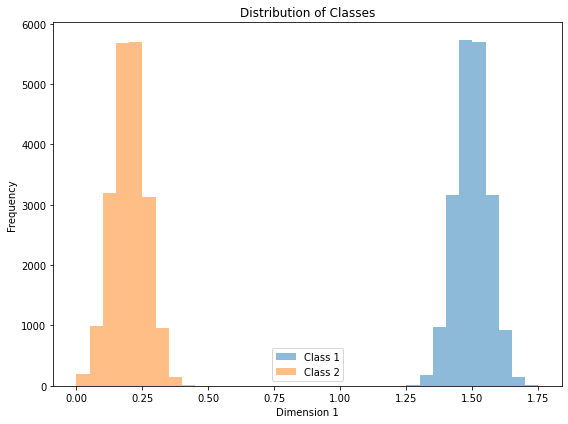

In [7]:
############################################################
################  Load classification data #################
############################################################

n_classes = 2

from sklearn import cluster, datasets
from sklearn.preprocessing import StandardScaler

data_type = "gaussian"
n_samples = 20000

if data_type == "gaussian":
######  Gaussian example
    
    input_dim = 1
    scale = 0.2

    mu_1 = scale*7.5e0 * np.ones(input_dim)
    cov_1 = scale**1 * 0.02 * np.diag(np.ones(input_dim))
    dist_1 = np.abs(np.random.multivariate_normal(mu_1, cov_1, n_samples))

    mu_2 = scale*1e0 * np.ones(input_dim)
    cov_2 = scale**1 *0.02 * np.diag(np.ones(input_dim))
    dist_2 = np.abs(np.random.multivariate_normal(mu_2, cov_2, n_samples))

    data_list = [[dat for dat in dist_1], [dat for dat in dist_2]]

elif data_type == "gaussians":
######  Gaussian example
    
    input_dim = 1
    scale = 5

    mu_1a = scale*2.5e0 * np.ones(input_dim)
    mu_1b = scale*7.5e0 * np.ones(input_dim)
    cov_1 = scale**1 * 0.02 * np.diag(np.ones(input_dim))
    dist_1a = np.abs(np.random.multivariate_normal(mu_1a, cov_1, int(n_samples)))
    dist_1b = np.abs(np.random.multivariate_normal(mu_1b, cov_1, int(n_samples)))
    dist_1 = np.concatenate([dist_1a, dist_1b], axis=0)

    mu_2 = scale*5e0 * np.ones(input_dim)
    cov_2 = scale**1 *0.02 * np.diag(np.ones(input_dim))
    dist_2 = np.abs(np.random.multivariate_normal(mu_2, cov_2, n_samples))

    data_list = [[dat for dat in dist_1], [dat for dat in dist_2]]

elif data_type == "moons":
    # Convert sklearn noisy_moons to same format as data_list,
    # allowing user to specify scale and offset
    noisy_moons_X, noisy_moons_y = datasets.make_moons(n_samples=n_samples, noise=0.05, random_state=170)

    # Specify the desired scale and offset here
    noisy_moons_scale = 10.0    # Change to your desired scale
    noisy_moons_offset = noisy_moons_scale * np.array([2.0, 2.0])  # Change for desired offset; must have shape (2,)

    # Apply scale and offset
    noisy_moons_X = noisy_moons_X * noisy_moons_scale + noisy_moons_offset
    data_list = [[dat for dat in noisy_moons_X[noisy_moons_y == i]] for i in range(2)]

elif data_type == "circle_vs_square":
    # Sample uniformly from square [0, 2*x_c] x [0, 2*x_c]
    # Class 0: Points inside circle centered at (x_c, x_c) with radius r
    # Class 1: Points outside the circle
    scale = 1
    offset = scale * 0.0
    x_c = scale * 5.0 + offset     # center coordinate
    r = scale * 3.0         # radius of circle
    
    dist_circle = []  # class 0: inside circle
    dist_square = []  # class 1: outside circle
    
    for _ in range(n_samples):
        # Sample uniformly from square [0, 2*x_c] x [0, 2*x_c]
        x = np.random.uniform(0, 2 * (x_c - offset)) + offset
        y = np.random.uniform(0, 2 * (x_c - offset)) + offset
        
        # Check if point is inside circle
        dist_from_center = np.sqrt((x - x_c)**2 + (y - x_c)**2)
        
        if dist_from_center <= r:
            dist_circle.append(np.array([x, y]))
        else:
            dist_square.append(np.array([x, y]))
    
    data_list = [dist_circle, dist_square]

elif data_type == "diagonal_cut":
    # Classify according to which side of the diagonal y = x the point is on
    # Class 0: y > x; Class 1: y <= x
    scale = 0.2
    offset = scale * 2.0
    x_c = scale * 5.0 + offset  # to keep square region similar to above
    dist_above = []   # class 0: y > x
    dist_below = []   # class 1: y <= x

    for _ in range(n_samples):
        x = np.random.uniform(0, 2 * (x_c - offset)) + offset
        y = np.random.uniform(0, 2 * (x_c - offset)) + offset

        if y > x:
            dist_above.append(np.array([x, y]))
        else:
            dist_below.append(np.array([x, y]))
    
    data_list = [dist_above, dist_below]

elif data_type == "bottom_quarter_intersect":
    # Class 0: Points in the bottom quarter region defined by the intersection of y = x and y = 1 - x
    # inside the square [0, 1] x [0, 1], then apply scale and offset
    # Class 1: All other points inside the [0, 1] x [0, 1] square, excluding class 0.
    # That region is the triangle below both lines: y <= x AND y <= 1 - x. This triangle's vertices are: (0,0), (0.5,0), (1,0)
    dist_bottom_quarter = []  # class 0
    dist_other = []           # class 1
    
    scale = 10
    offset = scale * 0.0

    for _ in range(n_samples):
        # generate point in [0,1]x[0,1]
        x = np.random.uniform(0, 1)
        y = np.random.uniform(0, 1)

        # Triangle: y <= x AND y <= 1-x
        if y <= x and y <= 1 - x:
            # Apply scale and offset before adding
            p = np.array([x, y]) * scale + offset
            dist_bottom_quarter.append(p)
        else:
            p = np.array([x, y]) * scale + offset
            dist_other.append(p)

    data_list = [dist_bottom_quarter, dist_other]


input_data = InputData(n_classes, data_list)

# Redefine dist_1 and dist_2 from data_list for legacy code compatibility, but now as np.arrays
dist_1 = np.vstack(data_list[0])
dist_2 = np.vstack(data_list[1])

plt.figure(figsize=(8, 6))
if dist_1.shape[1] == 1:
    # Use fixed-width bins based on the min/max over both classes
    all_x = np.concatenate([dist_1[:, 0], dist_2[:, 0]])
    bin_width = 0.05  # Set desired bin width here
    bins = np.arange(np.min(all_x), np.max(all_x) + bin_width, bin_width)
    plt.hist(dist_1[:, 0], bins=bins, alpha=0.5, label='Class 1')
    plt.hist(dist_2[:, 0], bins=bins, alpha=0.5, label='Class 2')
    plt.xlabel('Dimension 1')
    plt.ylabel('Frequency')
elif dist_1.shape[1] == 2:
    plt.scatter(dist_1[:, 0], dist_1[:, 1], alpha=0.3, s=1, label='Class 1')
    plt.scatter(dist_2[:, 0], dist_2[:, 1], alpha=0.3, s=1, label='Class 2')
    plt.xlabel('Dimension 1')
    plt.ylabel('Dimension 2')
else:
    # More than 2 dimensions: project to first two
    plt.scatter(dist_1[:, 0], dist_1[:, 1], alpha=0.3, s=1, label='Class 1')
    plt.scatter(dist_2[:, 0], dist_2[:, 1], alpha=0.3, s=1, label='Class 2')
    plt.xlabel('Dimension 1')
    plt.ylabel('Dimension 2')
plt.title('Distribution of Classes')
plt.legend()
plt.tight_layout()
plt.show()



In [8]:
import numpy as np
import random
import time
from CRNs.training import SimpleMLP, MLPModel, UnifiedTrainer

# ============== HYPERPARAMETERS ==============
# Network architecture
input_dim = NR
hidden_sizes = [4]
n_classes = len(target_node_idxs)
layer_sizes = [input_dim] + hidden_sizes + [n_classes]
mlp_activation = 'tanh'

# Training settings
batch_size = 20
num_epochs = int(5000)
num_batches = num_epochs // batch_size
print_every = 50

# Temperature annealing
T_start = 1.0
T_end = 0.2
T_decay = 0.99

# Gradient noise annealing
noise_scale_start = 1.0
noise_scale_end = 0.0
noise_decay = 0.9

# Loss and optimizer
loss_type = "cross_entropy"  # or "mse"
optimizer_type = "adam"

print(f"Using optimizer: {optimizer_type}")
print(f"Using loss type: {loss_type}")
print(f"MLP architecture: {layer_sizes}")

# ============== INITIALIZATION ==============
np.random.seed(42)
random.seed(42)

# Create MLP and wrap with MLPModel
mlp = SimpleMLP(layer_sizes, activation=mlp_activation)
model = MLPModel(mlp, n_classes=n_classes)
print(f"Total MLP parameters: {mlp.get_param_count()}")

# Create trainer
trainer = UnifiedTrainer(
    model=model,
    optimizer_type=optimizer_type,
    lr=0.2,
    beta1=0.95,
    beta2=0.99,
    eps=1e-8,
    max_grad_norm=50.0,
    loss_type=loss_type
)

# ============== TRACKING ==============
loss_list = [[] for _ in range(n_classes)]
avg_loss_history = []
accuracy_history = []
grad_norm_history = []
softmax_temperature_list = []
noise_scale_history = []

# ============== TRAINING LOOP ==============
start_time = time.time()
print(f"Starting training: {num_batches} batches, batch_size={batch_size}")
print("=" * 80)

for batch in range(num_batches):
    batch_loss = 0.0
    batch_correct = 0
    batch_valid = 0
    
    # Temperature annealing
    temperature = max(T_end, T_start * (T_decay ** batch))
    softmax_temperature_list.append(temperature)
    
    # Noise annealing
    noise_scale = max(noise_scale_end, noise_scale_start * (noise_decay ** batch))
    noise_scale_history.append(noise_scale)
    
    for sample in range(batch_size):
        class_number = random.randrange(n_classes)
        inputs = input_data.get_next_training_sample(class_number)
        x = np.array(inputs).flatten()
        
        try:
            # Single train_step handles forward, backward, and optimizer update
            loss, probs, grad_norms = trainer.train_step(
                inputs=x,
                target_idx=class_number,
                temperature=temperature,
                noise_scale=noise_scale
            )
            
            # Check for numerical issues
            if np.any(np.isnan(probs)) or np.any(np.isinf(probs)):
                print(f"  Warning: Invalid probs at batch {batch}, sample {sample}")
                continue
            
            batch_loss += loss
            loss_list[class_number].append(loss)
            
            if trainer.compute_accuracy(probs, class_number):
                batch_correct += 1
            batch_valid += 1
            
        except Exception as e:
            print(f"  Warning: Training step failed at batch {batch}, sample {sample}: {e}")
            continue
    
    # Skip if no valid samples
    if batch_valid == 0:
        print(f"  Batch {batch}: No valid samples, skipping")
        continue
    
    # ============== DIAGNOSTICS ==============
    avg_loss = batch_loss / batch_valid
    accuracy = batch_correct / batch_valid
    avg_loss_history.append(avg_loss)
    accuracy_history.append(accuracy)
    grad_norm_history.append(grad_norms.get('params', 0))
    
    if batch % print_every == 0 or batch == num_batches - 1:
        recent_window = min(100, len(avg_loss_history))
        recent_loss = np.mean(avg_loss_history[-recent_window:])
        recent_acc = np.mean(accuracy_history[-recent_window:])
        
        params = model.get_params()['params']
        print(f"Batch {batch:4d}/{num_batches} | "
              f"Loss: {avg_loss:.4f} (avg: {recent_loss:.4f}) | "
              f"Acc: {accuracy:.1%} (avg: {recent_acc:.1%}) | "
              f"GradNorm: {grad_norms.get('params', 0):.2e} | "
              f"Temp: {temperature:.2f} | "
              f"Noise: {noise_scale:.2e}")

end_time = time.time()
print("=" * 70)
print(f"Training complete in {end_time - start_time:.1f} seconds")
print(f"Final avg loss: {np.mean(avg_loss_history[-100:]):.4f}")
print(f"Final avg accuracy: {np.mean(accuracy_history[-100:]):.1%}")

params = model.get_params()['params']
print(f"Final param range: [{params.min():.2e}, {params.max():.2e}]")
print(f"Total parameters: {mlp.get_param_count()}")

Using optimizer: adam
Using loss type: cross_entropy
MLP architecture: [1, 4, 2]
Total MLP parameters: 18
Starting training: 250 batches, batch_size=20
Batch    0/250 | Loss: 0.2982 (avg: 0.2982) | Acc: 85.0% (avg: 85.0%) | GradNorm: 4.78e-01 | Temp: 1.00 | Noise: 1.00e+00
Batch   50/250 | Loss: 0.0000 (avg: 0.0060) | Acc: 100.0% (avg: 99.7%) | GradNorm: 3.88e-07 | Temp: 0.61 | Noise: 5.15e-03
Batch  100/250 | Loss: -0.0000 (avg: 0.0001) | Acc: 100.0% (avg: 100.0%) | GradNorm: 1.59e-12 | Temp: 0.37 | Noise: 2.66e-05
Batch  150/250 | Loss: -0.0000 (avg: -0.0000) | Acc: 100.0% (avg: 100.0%) | GradNorm: 1.39e-21 | Temp: 0.22 | Noise: 1.37e-07
Batch  200/250 | Loss: -0.0000 (avg: -0.0000) | Acc: 100.0% (avg: 100.0%) | GradNorm: 2.38e-22 | Temp: 0.20 | Noise: 7.06e-10
Batch  249/250 | Loss: -0.0000 (avg: -0.0000) | Acc: 100.0% (avg: 100.0%) | GradNorm: 7.63e-22 | Temp: 0.20 | Noise: 4.04e-12
Training complete in 0.7 seconds
Final avg loss: -0.0000
Final avg accuracy: 100.0%
Final param rang

In [3]:
# === Setup CRN Model with ODE forward ===
crn_model = CRNModel(
    r_n=r_n,
    sim=sim,
    L=L,
    class_ids=target_node_idxs,
    n_inputs=NR,
    default_l0=default_l0,
    forward_method='ode',  # or 'graph'
    graph_comp=graph_comp,  # needed if using 'graph'
    dR_dC_func=dR_dC_func,
    dR_dk_func=dR_dk_func,
    dR_dl_func=dR_dl_func,
    generate_init_func=generate_positive_initial_concentrations_nnls,
    t_span=(0, 100000),
    rtol=1e-12, atol=1e-12
)

# === Create trainer ===
trainer = UnifiedTrainer(
    model=crn_model,
    optimizer_type='adam',
    lr=0.2,
    lr_dict={'log_rates': 0.2, 'log_l0': 0.2},  # per-param LRs
    beta1=0.95, beta2=0.99,
    max_grad_norm=50.0,
    loss_type='cross_entropy'
)

# === Training loop ===
for batch in range(num_batches):
    temperature = max(T_end, T_start * (T_decay ** batch))
    noise_scale = max(0, noise_start * (noise_decay ** batch))
    
    for sample in range(batch_size):
        target_idx = random.randrange(n_classes)
        inputs = input_data.get_next_training_sample(target_idx)
        
        loss, probs, grad_norms = trainer.train_step(
            inputs, target_idx, 
            temperature=temperature,
            noise_scale=noise_scale
        )
        
        accuracy = trainer.compute_accuracy(probs, target_idx)

# === Switch to graph forward (same analytical gradients) ===
crn_model.set_forward_method('graph')

# # === Or use MLP instead ===
# mlp_model = MLPModel(mlp, n_classes=n_classes)
# trainer_mlp = UnifiedTrainer(mlp_model, lr=0.2)

NameError: name 'default_l0' is not defined

In [ ]:
import numpy as np
import random
import time




# ============== HYPERPARAMETERS ==============
# Network architecture
input_dim = NR  # Same as number of receptor inputs
hidden_sizes = [4]  # Hidden layer sizes
n_classes = len(target_node_idxs)
layer_sizes = [input_dim] + hidden_sizes + [n_classes]
mlp_activation = 'tanh'  # 'relu', 'tanh', 'sigmoid'

# Adam hyperparameters (same as original)
eta = 0.2            # learning rate (single LR for MLP)
beta1 = 0.95          # first moment decay
beta2 = 0.99          # second moment decay
eps_adam = 1e-8       # numerical stability

# Gradient clipping
max_grad_norm = 50.0

# Training settings (same as original)
batch_size = 20
num_epochs = int(5000)
num_batches = num_epochs // batch_size
print_every = 50

# Loss function and softmax settings (same as original)
loss_type = "cross_entropy"  # or "mse"
T_start = 1.0
T_end = 0.2
T_decay = 0.99
label_smoothing = 0.0

# Gradient noise hyperparameters (same as original)
noise_scale_start = 1.0
noise_scale_end = 0.0
noise_decay = 0.9

# Optimizer selection
optimizer_type = "adam"  # or "sgd"
print(f"Using optimizer: {optimizer_type}")
print(f"Using loss type: {loss_type}")
print(f"MLP architecture: {layer_sizes}")

# ============== INITIALIZATION ==============
np.random.seed(42)  # For reproducibility
random.seed(42)

mlp = SimpleMLP(layer_sizes, activation=mlp_activation)
n_params = mlp.get_param_count()
print(f"Total MLP parameters: {n_params}")

# Get initial flat parameters for Adam
flat_params = mlp.get_flat_params()

# Adam momentum variables
m = np.zeros_like(flat_params)
v = np.zeros_like(flat_params)

# ============== TRACKING ==============
loss_list = [[] for _ in range(n_classes)]
avg_loss_history = []
accuracy_history = []
grad_norm_history = []
param_stats_history = []
softmax_temperature_list = []
noise_scale_history = []

# ============== HELPER FUNCTIONS ==============
def clip_gradient(grad, max_norm):
    """Clip gradient by global norm."""
    grad_norm = np.linalg.norm(grad)
    if grad_norm > max_norm:
        return grad * (max_norm / grad_norm), grad_norm, True
    return grad, grad_norm, False

def flatten_grads(grad_weights, grad_biases):
    """Flatten gradient lists into single vector."""
    grads = []
    for dW, db in zip(grad_weights, grad_biases):
        grads.append(dW.flatten())
        grads.append(db.flatten())
    return np.concatenate(grads)

def compute_accuracy(probs, class_number):
    """Check if correct class has highest probability."""
    return np.argmax(probs) == class_number

# ============== TRAINING LOOP ==============
start_time = time.time()
print(f"Starting training: {num_batches} batches, batch_size={batch_size}")
print("=" * 80)

for batch in range(num_batches):
    grad_accum = np.zeros_like(flat_params)
    batch_loss = 0.0
    batch_correct = 0
    batch_valid = 0

    # Temperature annealing (same schedule as original)
    softmax_temperature = max(T_end, T_start * (T_decay ** batch))
    softmax_temperature_list.append(softmax_temperature)

    for sample in range(batch_size):
        class_number = random.randrange(n_classes)
        inputs = input_data.get_next_training_sample(class_number)
        
        # Normalize inputs (optional, but often helpful for MLPs)
        x = np.array(inputs).flatten()
        
        try:
            # Forward pass
            logits = mlp.forward(x)
            probs = mlp.softmax(logits, temperature=softmax_temperature)
            
            # Check for numerical issues
            if np.any(np.isnan(probs)) or np.any(np.isinf(probs)):
                print(f"  Warning: Invalid probs at batch {batch}, sample {sample}")
                continue
            
            # ----------------- LOSS AND GRADIENT COMPUTATION -----------------
            eps = 1e-8
            
            if loss_type == "cross_entropy":
                if label_smoothing > 0:
                    smooth_target = np.ones(n_classes) * (label_smoothing / n_classes)
                    smooth_target[class_number] = (1.0 - label_smoothing) + (label_smoothing / n_classes)
                    loss = -np.sum(smooth_target * np.log(probs + eps))
                    # For smoothed labels, need custom backward
                    # Gradient: sum over i of -smooth_target[i] * d(log p_i)/d(theta)
                    # This is more complex; for simplicity, use hard target backward
                    grad_weights, grad_biases = mlp.backward(probs, class_number, softmax_temperature)
                else:
                    target_prob = probs[class_number]
                    loss = -np.log(target_prob + eps)
                    grad_weights, grad_biases = mlp.backward(probs, class_number, softmax_temperature)
            
            elif loss_type == "mse":
                target_vec = np.zeros(n_classes)
                target_vec[class_number] = 1.0
                loss = 0.5 * np.sum((probs - target_vec) ** 2)
                grad_weights, grad_biases = mlp.backward_mse(probs, target_vec, softmax_temperature)
            
            else:
                raise ValueError(f"Unknown loss_type: {loss_type}")
            
            # Flatten gradients
            grad = flatten_grads(grad_weights, grad_biases)
            
            # Check for invalid gradients
            if np.any(np.isnan(grad)) or np.any(np.isinf(grad)):
                print(f"  Warning: Invalid gradient at batch {batch}, sample {sample}")
                continue
            
            grad_accum += grad
            batch_loss += loss
            loss_list[class_number].append(loss)
            
            # Track accuracy
            if compute_accuracy(probs, class_number):
                batch_correct += 1
            batch_valid += 1
            
        except Exception as e:
            print(f"  Warning: Forward/backward failed at batch {batch}, sample {sample}: {e}")
            continue

    # Skip update if no valid samples
    if batch_valid == 0:
        print(f"  Batch {batch}: No valid samples, skipping update")
        continue

    # Average gradients
    grad_accum /= batch_valid

    # Gradient clipping
    grad_accum, grad_norm, clipped = clip_gradient(grad_accum, max_grad_norm)

    # -------------------- GRADIENT NOISE INJECTION -----------------------
    noise_scale = max(noise_scale_end, noise_scale_start * (noise_decay ** batch))
    noise_scale_history.append(noise_scale)
    
    # Add Gaussian noise to gradients (scaled by gradient magnitude for stability)
    noise = np.random.randn(*grad_accum.shape) * noise_scale * (np.abs(grad_accum).mean() + 1e-8)
    grad_accum = grad_accum + noise
    # ---------------------------------------------------------------------

    # -------------------- OPTIMIZER STEP -----------------------
    t_adam = batch + 1

    if optimizer_type == "adam":
        m = beta1 * m + (1 - beta1) * grad_accum
        v = beta2 * v + (1 - beta2) * (grad_accum ** 2)
        m_hat = m / (1 - beta1 ** t_adam)
        v_hat = v / (1 - beta2 ** t_adam)
        flat_params = flat_params - eta * m_hat / (np.sqrt(v_hat) + eps_adam)
    elif optimizer_type == "sgd":
        flat_params = flat_params - eta * grad_accum
    else:
        raise ValueError(f"Unknown optimizer_type: {optimizer_type}")
    # ----------------------------------------------------------

    # Apply updates to MLP
    mlp.set_flat_params(flat_params)

    # ============== DIAGNOSTICS ==============
    avg_loss = batch_loss / batch_valid
    accuracy = batch_correct / batch_valid
    avg_loss_history.append(avg_loss)
    accuracy_history.append(accuracy)
    grad_norm_history.append(grad_norm)
    param_stats_history.append((flat_params.min(), flat_params.max(), flat_params.mean()))

    if batch % print_every == 0 or batch == num_batches - 1:
        recent_window = min(100, len(avg_loss_history))
        recent_loss = np.mean(avg_loss_history[-recent_window:])
        recent_acc = np.mean(accuracy_history[-recent_window:])

        print(f"Batch {batch:4d}/{num_batches} | "
              f"Loss: {avg_loss:.4f} (avg: {recent_loss:.4f}) | "
              f"Acc: {accuracy:.1%} (avg: {recent_acc:.1%}) | "
              f"GradNorm: {grad_norm:.2e} | "
              f"Temp: {softmax_temperature:.2f} | "
              f"Noise: {noise_scale:.2e}"
              + (" [CLIPPED]" if clipped else ""))

end_time = time.time()
print("=" * 70)
print(f"Training complete in {end_time - start_time:.1f} seconds")
print(f"Final avg loss: {np.mean(avg_loss_history[-100:]):.4f}")
print(f"Final avg accuracy: {np.mean(accuracy_history[-100:]):.1%}")
print(f"Final param range: [{flat_params.min():.2e}, {flat_params.max():.2e}]")
print(f"Total parameters: {n_params}")

Using optimizer: adam
Using loss type: cross_entropy
MLP architecture: [1, 4, 2]
Total MLP parameters: 18
Starting training: 250 batches, batch_size=20
Batch    0/250 | Loss: 0.7336 (avg: 0.7336) | Acc: 25.0% (avg: 25.0%) | GradNorm: 5.18e-01 | Temp: 1.00 | Noise: 1.00e+00
Batch   50/250 | Loss: 0.5274 (avg: 0.7009) | Acc: 90.0% (avg: 52.8%) | GradNorm: 8.65e-01 | Temp: 0.61 | Noise: 5.15e-03
Batch  100/250 | Loss: 0.1792 (avg: 0.5380) | Acc: 95.0% (avg: 68.5%) | GradNorm: 1.44e+00 | Temp: 0.37 | Noise: 2.66e-05
Batch  150/250 | Loss: 0.0033 (avg: 0.2158) | Acc: 100.0% (avg: 91.0%) | GradNorm: 8.19e-02 | Temp: 0.22 | Noise: 1.37e-07
Batch  200/250 | Loss: 0.0051 (avg: 0.0652) | Acc: 100.0% (avg: 98.2%) | GradNorm: 1.54e-01 | Temp: 0.20 | Noise: 7.06e-10
Batch  249/250 | Loss: 0.0213 (avg: 0.0535) | Acc: 100.0% (avg: 98.4%) | GradNorm: 5.68e-01 | Temp: 0.20 | Noise: 4.04e-12
Training complete in 0.4 seconds
Final avg loss: 0.0535
Final avg accuracy: 98.4%
Final param range: [-2.88e+00, 

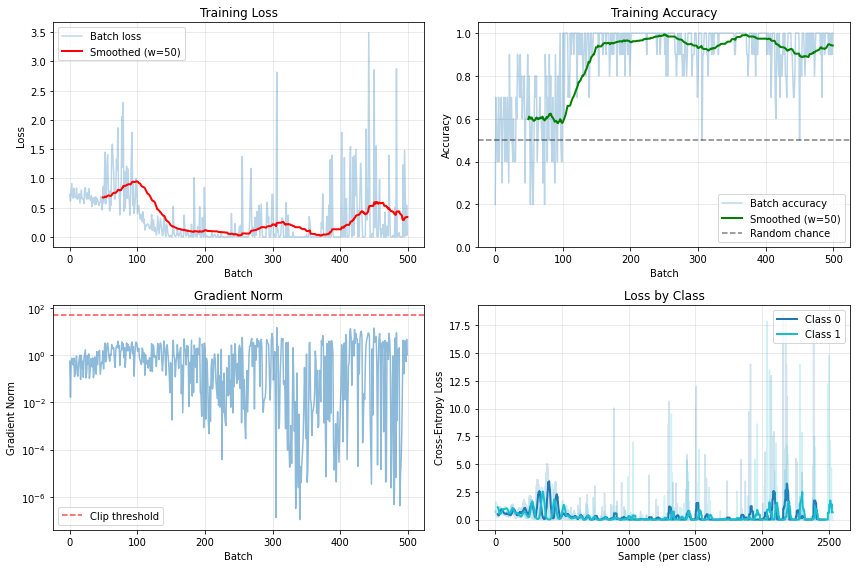

NameError: name 'ax4_twin' is not defined

In [216]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Plot 1: Loss over training
ax1 = axes[0, 0]
ax1.plot(avg_loss_history, alpha=0.3, label='Batch loss')
window = min(50, len(avg_loss_history) // 10 + 1)
if len(avg_loss_history) >= window:
    smoothed_loss = np.convolve(avg_loss_history, np.ones(window)/window, mode='valid')
    ax1.plot(range(window-1, len(avg_loss_history)), smoothed_loss, 'r-', linewidth=2, label=f'Smoothed (w={window})')
ax1.set_xlabel('Batch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Accuracy over training
ax2 = axes[0, 1]
ax2.plot(accuracy_history, alpha=0.3, label='Batch accuracy')
if len(accuracy_history) >= window:
    smoothed_acc = np.convolve(accuracy_history, np.ones(window)/window, mode='valid')
    ax2.plot(range(window-1, len(accuracy_history)), smoothed_acc, 'g-', linewidth=2, label=f'Smoothed (w={window})')
ax2.axhline(y=1/n_classes, color='k', linestyle='--', alpha=0.5, label='Random chance')
ax2.set_xlabel('Batch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training Accuracy')
ax2.set_ylim([0, 1.05])
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Gradient norm over training
ax3 = axes[1, 0]
ax3.semilogy(grad_norm_history, alpha=0.5)
ax3.axhline(y=max_grad_norm, color='r', linestyle='--', alpha=0.7, label='Clip threshold')
ax3.set_xlabel('Batch')
ax3.set_ylabel('Gradient Norm')
ax3.set_title('Gradient Norm')
ax3.legend()
ax3.grid(True, alpha=0.3)

# # Plot 4: Temperature and noise annealing
# ax4 = axes[1, 1]
# ax4.plot(softmax_temperature_list[:len(avg_loss_history)], 'b-', label='Softmax temperature')
# ax4.set_xlabel('Batch')
# ax4.set_ylabel('Temperature', color='b')
# ax4.tick_params(axis='y', labelcolor='b')

# ax4_twin = ax4.twinx()
# ax4_twin.plot(noise_scale_history, 'orange', label='Noise scale')
# ax4_twin.set_ylabel('Noise Scale', color='orange')
# ax4_twin.tick_params(axis='y', labelcolor='orange')

# ax4.set_title('Annealing Schedules')
# ax4.grid(True, alpha=0.3)

# Plot 4: Loss by class
ax4 = axes[1, 1]
colors = plt.cm.tab10(np.linspace(0, 1, n_classes))
for k in range(n_classes):
    if len(loss_list[k]) > 0:
        # Plot raw losses with transparency
        ax4.plot(loss_list[k], alpha=0.2, color=colors[k])
        # Plot smoothed version
        class_window = min(20, len(loss_list[k]) // 5 + 1)
        if len(loss_list[k]) >= class_window:
            smoothed = np.convolve(loss_list[k], np.ones(class_window)/class_window, mode='valid')
            ax4.plot(range(class_window-1, len(loss_list[k])), smoothed, 
                     color=colors[k], linewidth=2, label=f'Class {k}')
        else:
            ax4.plot(loss_list[k], color=colors[k], linewidth=2, label=f'Class {k}')

ax4.set_xlabel('Sample (per class)')
ax4.set_ylabel('Cross-Entropy Loss')
ax4.set_title('Loss by Class')
ax4.legend(loc='upper right')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Combine legends
lines1, labels1 = ax4.get_legend_handles_labels()
lines2, labels2 = ax4_twin.get_legend_handles_labels()
ax4.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\n{'='*50}")
print(f"Training Summary")
print(f"{'='*50}")
print(f"Final loss (last 100 batches): {np.mean(avg_loss_history[-100:]):.4f}")
print(f"Final accuracy (last 100 batches): {np.mean(accuracy_history[-100:]):.1%}")
print(f"Best accuracy: {max(accuracy_history):.1%}")
print(f"Min loss achieved: {min(avg_loss_history):.4f}")

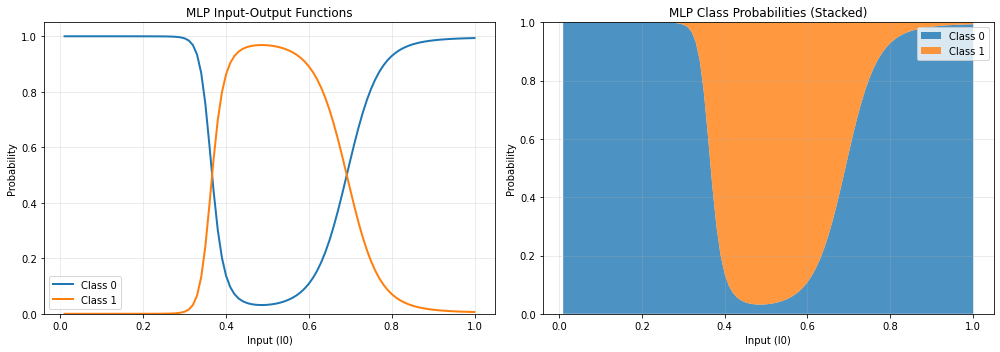


Decision boundaries at l0 values:
  l0 ≈ 0.36 -> 0.37: Class 0 -> Class 1
  l0 ≈ 0.69 -> 0.70: Class 1 -> Class 0


In [220]:
n_l0 = 100
l0_space = np.linspace(1e-2, 1, n_l0)
prob_array_mlp = np.zeros((n_classes, n_l0))

# Use final temperature or T=1.0 for evaluation
eval_temperature = 1.0  # or use T_end for consistency with training end

for i, l0_val in enumerate(l0_space):
    # Create input vector (same structure as training)
    x = np.ones(input_dim) * l0_val  # or however your inputs are structured
    # If inputs are more complex, use: x = input_data.get_input_for_value(l0_val)
    
    # Forward pass
    logits = mlp.forward(x)
    probs = mlp.softmax(logits, temperature=eval_temperature)
    
    prob_array_mlp[:, i] = probs

# Plot the input-output functions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: All classes on same plot
ax1 = axes[0]
for k in range(n_classes):
    ax1.plot(l0_space, prob_array_mlp[k, :], label=f'Class {k}', linewidth=2)
ax1.set_xlabel('Input (l0)')
ax1.set_ylabel('Probability')
ax1.set_title('MLP Input-Output Functions')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim([0, 1.05])

# Plot 2: Stacked area plot to show probability distribution
ax2 = axes[1]
ax2.stackplot(l0_space, prob_array_mlp, labels=[f'Class {k}' for k in range(n_classes)], alpha=0.8)
ax2.set_xlabel('Input (l0)')
ax2.set_ylabel('Probability')
ax2.set_title('MLP Class Probabilities (Stacked)')
ax2.legend(loc='upper right')
ax2.set_ylim([0, 1])
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print decision boundaries (where argmax changes)
predictions = np.argmax(prob_array_mlp, axis=0)
boundary_indices = np.where(np.diff(predictions) != 0)[0]
print(f"\nDecision boundaries at l0 values:")
for idx in boundary_indices:
    print(f"  l0 ≈ {l0_space[idx]:.2f} -> {l0_space[idx+1]:.2f}: Class {predictions[idx]} -> Class {predictions[idx+1]}")


#     # Side-by-side comparison (assuming you have both prob_array and prob_array_mlp)
# fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# # Reaction network
# ax1 = axes[0]
# for k in range(len(class_ids)):
#     ax1.plot(l0_space, prob_array[k, :], label=f'Class {k}', linewidth=2)
# ax1.set_xlabel('Input (l0)')
# ax1.set_ylabel('Probability')
# ax1.set_title('Reaction Network')
# ax1.legend()
# ax1.grid(True, alpha=0.3)
# ax1.set_ylim([0, 1.05])

# # MLP
# ax2 = axes[1]
# for k in range(n_classes):
#     ax2.plot(l0_space, prob_array_mlp[k, :], label=f'Class {k}', linewidth=2)
# ax2.set_xlabel('Input (l0)')
# ax2.set_title('MLP')
# ax2.legend()
# ax2.grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()

In [266]:
import numpy as np
import cma
import time

# ============== CMA-ES HYPERPARAMETERS ==============
sigma0 = 2           # initial step size (in log space)
popsize = 20           # population size (None = default 4 + 3*ln(n))
maxiter = 500          # maximum iterations
tolx = 1e-8            # termination tolerance on x
tolfun = 1e-11         # termination tolerance on function value
n_samples_per_eval = 10  # samples to average per fitness evaluation

# ============== INITIALIZATION ==============
rates = generate_thermodynamic_rates(r_n, C0, beta, E_range, B_range, F_range)
log_rates = np.log(rates)
r_n.update_rates(rates)
n_rates = len(rates)

class_ids = target_node_idxs
print(f"Target species: {[r_n.species_names[idx] for idx in target_node_idxs]}")

default_l0 = np.ones(NR + NS)
log_l0 = np.log(default_l0)
l0_range = [NR, (NR + NS) - len(class_ids)]

# Pack parameters into single vector
x0 = np.concatenate([log_rates, log_l0[l0_range[0]:l0_range[1]]])
n_rate_params = len(log_rates)
n_l0_params = l0_range[1] - l0_range[0]
print(f"Total parameters: {len(x0)} (rates: {n_rate_params}, l0: {n_l0_params})")

# ============== TRACKING ==============
loss_history = []
accuracy_history = []
best_loss_history = []
generation_history = []

# ============== OBJECTIVE FUNCTION ==============
def objective_function(x, n_samples=n_samples_per_eval):
    """
    Evaluate fitness (loss) for a parameter vector.
    Lower is better for CMA-ES minimization.
    """
    # Unpack parameters
    log_rates_local = x[:n_rate_params]
    log_l0_local = x[n_rate_params:]
    
    # Convert from log space
    rates_local = np.exp(log_rates_local)
    r_n.update_rates(rates_local)
    
    l0_template = default_l0.copy()
    l0_template[l0_range[0]:l0_range[1]] = np.exp(log_l0_local)
    
    total_loss = 0.0
    n_valid = 0
    n_correct = 0
    
    for _ in range(n_samples):
        class_number = random.randrange(n_classes)
        inputs = input_data.get_next_training_sample(class_number)
        l0 = l0_template.copy()
        l0[:NR] = inputs
        
        try:
            C_full = generate_positive_initial_concentrations_nnls(L, l0)
            _, C_reduced_init = sim.get_const_and_reduced_init(C_full)
            sim.make_reduced_rhs_with_conservation(l0)
            
            sol_reduced, C_reduced_final = sim.integrate(
                sim.reduced_ode_rhs, C_reduced_init, t_span=t_span,
                num_points=num_points, method='LSODA', rtol=r_tol, atol=a_tol
            )
            
            C_full = sim.recover_eliminated_species(l0, C_reduced_final)
            
            # Compute softmax probabilities
            C_class = np.array([C_full[class_ids[i]] for i in range(n_classes)])
            temperature = 1.0  # fixed temperature for CMA-ES
            logits = C_class / temperature
            logits_shifted = logits - np.max(logits)
            exp_logits = np.exp(logits_shifted)
            probs = exp_logits / np.sum(exp_logits)
            
            # Check for numerical issues
            if np.any(np.isnan(probs)) or np.any(np.isinf(probs)):
                continue
            
            # Cross-entropy loss
            eps = 1e-8
            loss = -np.log(probs[class_number] + eps)
            
            if not (np.isnan(loss) or np.isinf(loss)):
                total_loss += loss
                n_valid += 1
                
                # Track accuracy
                if probs[class_number] == max(probs):
                    n_correct += 1
                    
        except Exception as e:
            continue
    
    if n_valid == 0:
        return 1e6  # penalty for failed evaluation
    
    avg_loss = total_loss / n_valid
    accuracy = n_correct / n_valid
    
    return avg_loss

# ============== CMA-ES OPTIONS ==============
opts = {
    'popsize': popsize,
    'maxiter': maxiter,
    'tolx': tolx,
    'tolfun': tolfun,
    'verb_disp': 1,        # print every generation
    'verb_log': 0,         # no file logging
    'CMA_active': True,    # use active covariance update
    # 'CMA_diagonal': False,  # set True for sep-CMA-ES
    # 'seed': 42,           # for reproducibility
}

# ============== RUN CMA-ES ==============
print("=" * 70)
print(f"Starting CMA-ES optimization")
print(f"  Population size: {popsize}")
print(f"  Samples per evaluation: {n_samples_per_eval}")
print(f"  Parameter dimension: {len(x0)}")
print("=" * 70)

start_time = time.time()

es = cma.CMAEvolutionStrategy(x0, sigma0, opts)

generation = 0
while not es.stop():
    # Ask for candidate solutions
    solutions = es.ask()
    
    # Evaluate fitness for each candidate
    fitness_values = [objective_function(x) for x in solutions]
    
    # Tell CMA-ES the results
    es.tell(solutions, fitness_values)
    
    # Logging
    es.disp()
    
    # Track best solution
    best_idx = np.argmin(fitness_values)
    best_loss = fitness_values[best_idx]
    best_loss_history.append(best_loss)
    generation_history.append(generation)
    
    # Evaluate accuracy on best solution periodically
    if generation % 10 == 0:
        best_x = solutions[best_idx]
        # Quick accuracy check
        acc_samples = 50
        log_rates_best = best_x[:n_rate_params]
        log_l0_best = best_x[n_rate_params:]
        rates_best = np.exp(log_rates_best)
        r_n.update_rates(rates_best)
        
        l0_template = default_l0.copy()
        l0_template[l0_range[0]:l0_range[1]] = np.exp(log_l0_best)
        
        correct = 0
        valid = 0
        for _ in range(acc_samples):
            class_number = random.randrange(n_classes)
            inputs = input_data.get_next_training_sample(class_number)
            l0 = l0_template.copy()
            l0[:NR] = inputs
            try:
                C_full = generate_positive_initial_concentrations_nnls(L, l0)
                _, C_reduced_init = sim.get_const_and_reduced_init(C_full)
                sim.make_reduced_rhs_with_conservation(l0)
                sol_reduced, C_reduced_final = sim.integrate(
                    sim.reduced_ode_rhs, C_reduced_init, t_span=t_span,
                    num_points=num_points, method='LSODA', rtol=r_tol, atol=a_tol
                )
                C_full = sim.recover_eliminated_species(l0, C_reduced_final)
                C_class = np.array([C_full[class_ids[i]] for i in range(n_classes)])
                probs = np.exp(C_class) / np.sum(np.exp(C_class))
                if probs[class_number] == max(probs):
                    correct += 1
                valid += 1
            except:
                pass
        if valid > 0:
            accuracy_history.append(correct / valid)
            print(f"  Gen {generation}: Accuracy = {correct/valid:.1%}")
    
    generation += 1

end_time = time.time()

# ============== EXTRACT BEST SOLUTION ==============
best_x = es.result.xbest
best_fitness = es.result.fbest

# Unpack final parameters
log_rates = best_x[:n_rate_params]
log_l0_optimized = best_x[n_rate_params:]

rates = np.exp(log_rates)
r_n.update_rates(rates)
default_l0[l0_range[0]:l0_range[1]] = np.exp(log_l0_optimized)

print("=" * 70)
print(f"CMA-ES optimization complete in {end_time - start_time:.1f} seconds")
print(f"Generations: {generation}")
print(f"Best loss: {best_fitness:.4f}")
print(f"Final rate range: [{rates.min():.2e}, {rates.max():.2e}]")
print(f"Stop reason: {es.stop()}")
print("=" * 70)

# ============== PLOTTING ==============
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(generation_history, best_loss_history)
axes[0].set_xlabel('Generation')
axes[0].set_ylabel('Best Loss')
axes[0].set_title('CMA-ES Loss Convergence')
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3)

if accuracy_history:
    axes[1].plot(range(0, generation, 10)[:len(accuracy_history)], accuracy_history)
    axes[1].set_xlabel('Generation')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Classification Accuracy')
    axes[1].set_ylim([0, 1])
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Target species: ['S5', 'S6']
Total parameters: 49 (rates: 44, l0: 5)
Starting CMA-ES optimization
  Population size: 20
  Samples per evaluation: 10
  Parameter dimension: 49
(10_w,20)-aCMA-ES (mu_w=5.9,w_1=27%) in dimension 49 (seed=999045, Thu Dec  4 20:31:12 2025)
Iterat #Fevals   function value  axis ratio  sigma  min&max std  t[m:s]
    1     20 5.603871035440033e-01 1.0e+00 1.88e+00  2e+00  2e+00 0:07.4
  Gen 0: Accuracy = 56.0%
    2     40 6.364945872800064e-01 1.0e+00 1.79e+00  2e+00  2e+00 0:15.9
    3     60 5.461847102566307e-01 1.1e+00 1.74e+00  2e+00  2e+00 0:23.3
    4     80 5.348098834520587e-01 1.1e+00 1.70e+00  2e+00  2e+00 0:30.4
    5    100 6.034873288161255e-01 1.1e+00 1.70e+00  2e+00  2e+00 0:39.2
    6    120 5.700102641292988e-01 1.1e+00 1.69e+00  2e+00  2e+00 0:47.0
    7    140 5.484525150297536e-01 1.1e+00 1.65e+00  2e+00  2e+00 0:54.6
    8    160 6.031266796511146e-01 1.1e+00 1.61e+00  2e+00  2e+00 1:03.1
    9    180 5.351665058856198e-01 1.1e+00 1.58e+0

KeyboardInterrupt: 

In [264]:
import numpy as np
import random
import time

def normalize(vec, norm):
    return vec / norm

def compute_normalized_gradients(C_full, dC_dk_full, dC_dl_full, class_ids):
    outputs = [C_full[class_ids[i]] for i in range(len(class_ids))]
    output_grads = [dC_dk_full[class_ids[i]] for i in range(len(class_ids))]
    output_grads_dl = [dC_dl_full[class_ids[i]] for i in range(len(class_ids))]
    norm = np.sum(outputs)
    probs = normalize(C_full, norm)
    dprobs_dk = dC_dk_full / norm - np.outer(np.array(C_full), np.array(np.sum(output_grads, axis=0)) / norm**2)
    dprobs_dl = dC_dl_full / norm - np.outer(np.array(C_full), np.array(np.sum(output_grads_dl, axis=0)) / norm**2)
    return probs, dprobs_dk, dprobs_dl

def compute_softmax_gradients(C_full, dC_dk_full, dC_dl_full, class_ids, temperature=1.0):
    """
    Compute probabilities and gradients using softmax readout.
    """
    n_classes = len(class_ids)

    # ============== FORWARD PASS ==============
    # Extract concentrations at class nodes
    C_class = np.array([C_full[class_ids[i]] for i in range(n_classes)])

    # Softmax: p_i = exp(C_i / T) / sum(exp(C_j / T))
    logits = C_class / temperature
    logits_shifted = logits - np.max(logits)  # numerical stability
    exp_logits = np.exp(logits_shifted)
    softmax_sum = np.sum(exp_logits)
    probs_class = exp_logits / softmax_sum

    # ============== BACKWARD PASS ==============
    # Jacobian of softmax w.r.t. C
    # dp_i/dC_j = p_i * (delta_ij - p_j) / T
    softmax_jacobian = (np.diag(probs_class) - np.outer(probs_class, probs_class)) / temperature
    # shape: (n_classes, n_classes)

    # Extract dC/dk and dC/dl at class nodes
    dC_dk_class = np.array([dC_dk_full[class_ids[i]] for i in range(n_classes)])  # (n_classes, n_rates)
    dC_dl_class = np.array([dC_dl_full[class_ids[i]] for i in range(n_classes)])  # (n_classes, n_l)

    # dp/dk = sum_j (dp/dC_j * dC_j/dk)
    dprobs_dk_class = softmax_jacobian @ dC_dk_class  # (n_classes, n_rates)
    dprobs_dl_class = softmax_jacobian @ dC_dl_class  # (n_classes, n_l)

    # ============== PACK INTO FULL ARRAYS ==============
    probs_full = np.zeros_like(C_full)
    for i, idx in enumerate(class_ids):
        probs_full[idx] = probs_class[i]

    n_species = len(C_full)
    n_rates = dC_dk_full.shape[1]
    n_l = dC_dl_full.shape[1]

    dprobs_dk_full = np.zeros((n_species, n_rates))
    dprobs_dl_full = np.zeros((n_species, n_l))

    for i, idx in enumerate(class_ids):
        dprobs_dk_full[idx] = dprobs_dk_class[i]
        dprobs_dl_full[idx] = dprobs_dl_class[i]

    return probs_full, dprobs_dk_full, dprobs_dl_full


# ============== HYPERPARAMETERS ==============
E_range = 0.0
B_range = 0.0
F_range = 0.0
C0 = 1
beta = 1

# Integration settings
t_span = (0, 100000)
num_points = 10000
r_tol = 1e-12
a_tol = 1e-12

# Adam hyperparameters
eta_k = 0.2          # learning rate for rates
eta_l = 0.2          # learning rate for l0
beta1 = 0.95          # first moment decay
beta2 = 0.99         # second moment decay
eps_adam = 1e-8       # numerical stability

# Gradient clipping
max_grad_norm_k = 50.0
max_grad_norm_l = 50.0

# Training settings
batch_size = 20       # increased from 2
num_epochs = int(8000) #batch_size * 200
num_batches = num_epochs // batch_size
print_every = 50      # print diagnostics every N batches

# ===== Custom: Loss function and optimizer selection =====
# Possible values: 'cross_entropy', 'mse'
# loss_type = "mse"  # or "mse"
# gradient_type = "normalized"  # or "normalized" or "softmax"
loss_type = "cross_entropy"  # or "mse"
gradient_type = "softmax"  # or "normalized" or "softmax"
T_start = 1.0
T_end = 0.2
T_decay = 0.99
warmup_batches = 0
label_smoothing = 0.0

# Gradient noise hyperparameters (for annealed noise injection)
noise_scale_start = 5.0   # initial noise standard deviation
noise_scale_end = 0.0    # final noise standard deviation  
noise_decay = 0.99        # decay rate per batch (similar to temperature annealing)

# ------------ NEW: optimizer selection --------------
# Possible values: 'adam', 'sgd'
optimizer_type = "adam"  # or "sgd"
print(f"Using optimizer: {optimizer_type}")
print(f"Using loss type: {loss_type}")

# ============== INITIALIZATION ==============
rates = generate_thermodynamic_rates(r_n, C0, beta, E_range, B_range, F_range)
log_rates = np.log(rates)
r_n.update_rates(rates)
n_rates = len(rates)

class_ids = target_node_idxs
print(f"Target species: {[r_n.species_names[idx] for idx in target_node_idxs]}")
l_ind = NR + NS - 1

default_l0 = np.ones(NR + NS)
log_l0 = np.log(default_l0)
l0_range = [NR, (NR + NS) - len(class_ids)]
#l0_range = [NR, (NR + NS)]

# Adam momentum variables
m_k = np.zeros_like(log_rates)  # first moment for rates
v_k = np.zeros_like(log_rates)  # second moment for rates
m_l = np.zeros_like(log_l0)     # first moment for l0
v_l = np.zeros_like(log_l0)     # second moment for l0

# ============== TRACKING ==============
loss_list = [[] for _ in range(len(class_ids))]
avg_loss_history = []
accuracy_history = []
grad_norm_history = []
rate_stats_history = []
softmax_temperature_list = []
eta_k_history = []
eta_l_history = []
noise_scale_history = []

# ============== HELPER FUNCTIONS ==============
def clip_gradient(grad, max_norm):
    """Clip gradient by global norm."""
    grad_norm = np.linalg.norm(grad)
    if grad_norm > max_norm:
        return grad * (max_norm / grad_norm), grad_norm, True
    return grad, grad_norm, False

def compute_accuracy(probs, class_number, class_ids):
    """Check if correct class has highest probability."""
    target_prob = probs[class_ids[class_number]]
    other_probs = [probs[class_ids[i]] for i in range(len(class_ids)) if i != class_number]
    return target_prob > max(other_probs) if other_probs else True

# ============== TRAINING LOOP ==============
start_time = time.time()
print(f"Starting training: {num_batches} batches, batch_size={batch_size}")
print("=" * 80)

for batch in range(num_batches):
    grad_accum_k = np.zeros_like(log_rates)
    grad_accum_l = np.zeros_like(log_l0)
    batch_loss = 0.0
    batch_correct = 0
    batch_valid = 0

    for sample in range(batch_size):
        class_number = random.randrange(n_classes)
        inputs = input_data.get_next_training_sample(class_number)
        l0 = default_l0.copy()
        l0[:NR] = inputs

        try:
            C_full = generate_positive_initial_concentrations_nnls(L, l0)
            _, C_reduced_init = sim.get_const_and_reduced_init(C_full)
            sim.make_reduced_rhs_with_conservation(l0)

            sol_reduced, C_reduced_final = sim.integrate(
                sim.reduced_ode_rhs, C_reduced_init, t_span=t_span,
                num_points=num_points, method='LSODA', rtol=r_tol, atol=a_tol
            )

            C_full = sim.recover_eliminated_species(l0, C_reduced_final)
            dC_dk = sim.dC_dk_func(C_reduced_final, l0, rates, dR_dC_func, dR_dk_func)
            dC_dk_full = sim.compute_dC_dk_full(dC_dk, l_bool=False)

            dC_dl = sim.dC_dl_func(C_reduced_final, l0, rates, dR_dC_func, dR_dl_func)
            dC_dl_full = sim.compute_dC_dk_full(dC_dl, l_bool=True)

            if gradient_type == "normalized":
                probs, dprobs_dk_full, dprobs_dl_full = compute_normalized_gradients(
                    C_full, dC_dk_full, dC_dl_full, class_ids
                )
            elif gradient_type == "softmax":
                # 2. Temperature annealing
                softmax_temperature = max(T_end, T_start * (T_decay ** batch))
                softmax_temperature_list.append(softmax_temperature)
                probs, dprobs_dk_full, dprobs_dl_full = compute_softmax_gradients(
                    C_full, dC_dk_full, dC_dl_full, class_ids,
                    temperature=softmax_temperature
                )
            elif gradient_type == "hinge":
                probs, dprobs_dk_full, dprobs_dl_full = compute_hingeloss_gradients(
                    C_full, dC_dk_full, dC_dl_full, class_ids, margin=1.0
                )
            else:
                raise ValueError(f"Unknown gradient_type: {gradient_type}")

            # Check for numerical issues
            if np.any(np.isnan(probs)) or np.any(np.isinf(probs)):
                print(f"  Warning: Invalid probs at batch {batch}, sample {sample}")
                continue

            # ----------------- LOSS AND GRADIENT SELECTION -----------------
            eps = 1e-8  # numerical stability

            # Prepare ground truth and prediction vector for the classes
            target_vec = np.zeros(len(class_ids))
            target_vec[class_number] = 1.0
            p_vec = np.array([probs[class_ids[i]] for i in range(len(class_ids))])
            dpdk_vec = np.array([dprobs_dk_full[class_ids[i]] for i in range(len(class_ids))])
            dpdl_vec = np.array([dprobs_dl_full[class_ids[i]] for i in range(len(class_ids))])

            if loss_type == "cross_entropy":
                if label_smoothing > 0:
                    smooth_target = np.ones(n_classes) * (label_smoothing / n_classes)
                    smooth_target[class_number] = (1.0 - label_smoothing) + (label_smoothing / n_classes)
                    loss = -np.sum(smooth_target * np.log(p_vec + eps))
                    grad_weights = -smooth_target / (p_vec + eps)
                    grad_k = np.sum(grad_weights[:, None] * dpdk_vec, axis=0)
                    grad_l = np.sum(grad_weights[:, None] * dpdl_vec, axis=0)
                else:
                    # Original hard-target cross-entropy
                    target_prob = probs[class_ids[class_number]]
                    loss = -np.log(target_prob + eps)
                    grad_k = -dprobs_dk_full[class_ids[class_number]] / (target_prob + eps)
                    grad_l = -dprobs_dl_full[class_ids[class_number]] / (target_prob + eps)

            elif loss_type == "mse":
                # Mean Squared Error: loss = 0.5 * sum((p_i - y_i)^2)
                # Gradient: (p_i - y_i) * dp_i/dtheta summed over i
                loss = 0.5 * np.sum((p_vec - target_vec) ** 2)
                # Chain rule: sum_i ((p_i - y_i) * dp_i/dtheta)
                grad_k = np.sum((p_vec - target_vec)[:, None] * dpdk_vec, axis=0)
                grad_l = np.sum((p_vec - target_vec)[:, None] * dpdl_vec, axis=0)
            
            else:
                raise ValueError(f"Unknown loss_type: {loss_type}")
            # ----------------------------------------------------------------

            # Check for invalid gradients
            if np.any(np.isnan(grad_k)) or np.any(np.isinf(grad_k)):
                print(f"  Warning: Invalid grad_k at batch {batch}, sample {sample}")
                continue
            if np.any(np.isnan(grad_l)) or np.any(np.isinf(grad_l)):
                print(f"  Warning: Invalid grad_l at batch {batch}, sample {sample}")
                continue

            grad_accum_k += grad_k
            grad_accum_l += grad_l
            batch_loss += loss
            loss_list[class_number].append(loss)

            # Track accuracy
            if compute_accuracy(probs, class_number, class_ids):
                batch_correct += 1
            batch_valid += 1

        except Exception as e:
            print(f"  Warning: Integration failed at batch {batch}, sample {sample}: {e}")
            continue

    # Skip update if no valid samples
    if batch_valid == 0:
        print(f"  Batch {batch}: No valid samples, skipping update")
        continue

    # Average gradients
    grad_accum_k /= batch_valid
    grad_accum_l /= batch_valid

    # Gradient clipping
    grad_accum_k, grad_norm_k, clipped_k = clip_gradient(grad_accum_k, max_grad_norm_k)
    grad_accum_l, grad_norm_l, clipped_l = clip_gradient(grad_accum_l, max_grad_norm_l)

    # -------------------- GRADIENT NOISE INJECTION -----------------------
    # Anneal noise scale: starts high, decays to near zero
    noise_scale = max(noise_scale_end, noise_scale_start * (noise_decay ** batch))
    noise_scale_history.append(noise_scale)
    
    # Add Gaussian noise to gradients (scaled by gradient magnitude for stability)
    noise_k = np.random.randn(*grad_accum_k.shape) * noise_scale * (np.abs(grad_accum_k).mean() + 1e-8)
    noise_l = np.random.randn(*grad_accum_l.shape) * noise_scale * (np.abs(grad_accum_l).mean() + 1e-8)
    
    grad_accum_k = grad_accum_k + noise_k
    grad_accum_l = grad_accum_l + noise_l
    # ---------------------------------------------------------------------

    # -------------------- OPTIMIZER STEP -----------------------
    t_adam = batch + 1  # timestep for bias correction

    current_eta_k = eta_k 
    current_eta_l = eta_l 

    if optimizer_type == "adam":
        # Adam update for rates (in log space)
        g_k = grad_accum_k * rates  # chain rule: d/d(log_k) = d/dk * k
        m_k = beta1 * m_k + (1 - beta1) * g_k
        v_k = beta2 * v_k + (1 - beta2) * (g_k ** 2)
        m_k_hat = m_k / (1 - beta1 ** t_adam)
        v_k_hat = v_k / (1 - beta2 ** t_adam)
        log_rates = log_rates - current_eta_k * m_k_hat / (np.sqrt(v_k_hat) + eps_adam)

        g_l = grad_accum_l * default_l0  # chain rule
        m_l = beta1 * m_l + (1 - beta1) * g_l
        v_l = beta2 * v_l + (1 - beta2) * (g_l ** 2)
        m_l_hat = m_l / (1 - beta1 ** t_adam)
        v_l_hat = v_l / (1 - beta2 ** t_adam)
        log_l0 = log_l0 - current_eta_l * m_l_hat / (np.sqrt(v_l_hat) + eps_adam)
    elif optimizer_type == "sgd":
        # Vanilla SGD step (equivalent to Adam with no moments)
        # Using the same learning rate variables for consistency
        log_rates = log_rates - current_eta_k * grad_accum_k * rates
        log_l0 = log_l0 - current_eta_l * grad_accum_l * default_l0
    else:
        raise ValueError(f"Unknown optimizer_type: {optimizer_type}")
    # ----------------------------------------------------------

    # Apply updates
    rates = np.exp(log_rates)
    r_n.update_rates(rates)
    default_l0[l0_range[0]:l0_range[1]] = np.exp(log_l0[l0_range[0]:l0_range[1]])

    # ============== DIAGNOSTICS ==============
    avg_loss = batch_loss / batch_valid
    accuracy = batch_correct / batch_valid
    avg_loss_history.append(avg_loss)
    accuracy_history.append(accuracy)
    grad_norm_history.append((grad_norm_k, grad_norm_l))
    rate_stats_history.append((rates.min(), rates.max(), rates.mean()))

    if batch % print_every == 0 or batch == num_batches - 1:
        # Compute running averages
        recent_window = min(100, len(avg_loss_history))
        recent_loss = np.mean(avg_loss_history[-recent_window:])
        recent_acc = np.mean(accuracy_history[-recent_window:])

        print(f"Batch {batch:4d}/{num_batches} | "
              f"Loss: {avg_loss:.4f} (avg: {recent_loss:.4f}) | "
              f"Acc: {accuracy:.1%} (avg: {recent_acc:.1%}) | "
              f"GradNorm k:{grad_norm_k:.2e} l:{grad_norm_l:.2e} | "
              f"Rates: [{rates.min():.2e}, {rates.max():.2e}]"
              + (" [CLIPPED]" if clipped_k or clipped_l else ""))   

end_time = time.time()
print("=" * 70)
print(f"Training complete in {end_time - start_time:.1f} seconds")
print(f"Final avg loss: {np.mean(avg_loss_history[-100:]):.4f}")
print(f"Final avg accuracy: {np.mean(accuracy_history[-100:]):.1%}")
print(f"Final rate range: [{rates.min():.2e}, {rates.max():.2e}]")

Using optimizer: adam
Using loss type: cross_entropy
Target species: ['S5', 'S6']
Starting training: 400 batches, batch_size=20
Batch    0/400 | Loss: 0.6931 (avg: 0.6931) | Acc: 5.0% (avg: 5.0%) | GradNorm k:3.21e-02 l:1.06e-01 | Rates: [8.19e-01, 1.22e+00]
Batch   50/400 | Loss: 0.7328 (avg: 0.6925) | Acc: 40.0% (avg: 51.1%) | GradNorm k:1.39e-01 l:3.26e-01 | Rates: [2.26e-02, 9.63e+00]
Batch  100/400 | Loss: 0.6792 (avg: 0.6953) | Acc: 70.0% (avg: 50.7%) | GradNorm k:5.60e-02 l:6.77e-01 | Rates: [2.02e-02, 3.24e+01]
Batch  150/400 | Loss: 0.6992 (avg: 0.6966) | Acc: 35.0% (avg: 48.6%) | GradNorm k:5.65e-02 l:1.01e+00 | Rates: [1.93e-02, 5.60e+02]
Batch  200/400 | Loss: 0.6932 (avg: 0.6942) | Acc: 50.0% (avg: 49.3%) | GradNorm k:8.63e-04 l:2.23e-02 | Rates: [1.73e-02, 4.63e+02]
Batch  250/400 | Loss: 0.6951 (avg: 0.6932) | Acc: 30.0% (avg: 50.3%) | GradNorm k:5.88e-02 l:1.43e+00 | Rates: [1.71e-02, 4.29e+02]
Batch  300/400 | Loss: 0.6934 (avg: 0.6933) | Acc: 45.0% (avg: 50.0%) | Grad

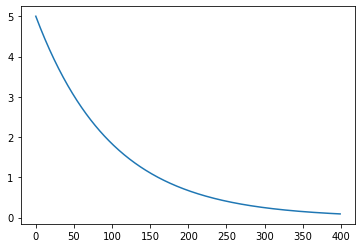

In [260]:
plt.plot(noise_scale_history)

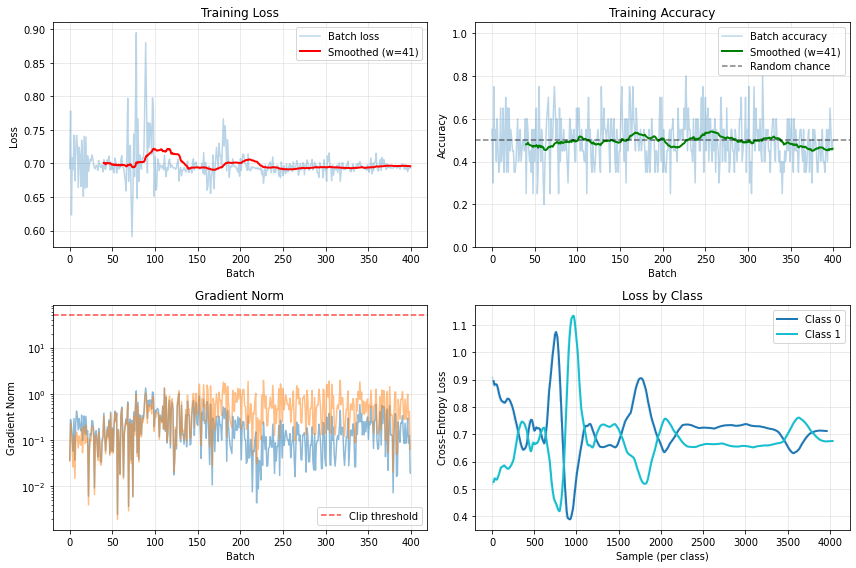

NameError: name 'ax4_twin' is not defined

In [261]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Plot 1: Loss over training
ax1 = axes[0, 0]
ax1.plot(avg_loss_history, alpha=0.3, label='Batch loss')
window = min(50, len(avg_loss_history) // 10 + 1)
if len(avg_loss_history) >= window:
    smoothed_loss = np.convolve(avg_loss_history, np.ones(window)/window, mode='valid')
    ax1.plot(range(window-1, len(avg_loss_history)), smoothed_loss, 'r-', linewidth=2, label=f'Smoothed (w={window})')
ax1.set_xlabel('Batch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Accuracy over training
ax2 = axes[0, 1]
ax2.plot(accuracy_history, alpha=0.3, label='Batch accuracy')
if len(accuracy_history) >= window:
    smoothed_acc = np.convolve(accuracy_history, np.ones(window)/window, mode='valid')
    ax2.plot(range(window-1, len(accuracy_history)), smoothed_acc, 'g-', linewidth=2, label=f'Smoothed (w={window})')
ax2.axhline(y=1/n_classes, color='k', linestyle='--', alpha=0.5, label='Random chance')
ax2.set_xlabel('Batch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training Accuracy')
ax2.set_ylim([0, 1.05])
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Gradient norm over training
ax3 = axes[1, 0]
ax3.semilogy(grad_norm_history, alpha=0.5)
ax3.axhline(y=max_grad_norm, color='r', linestyle='--', alpha=0.7, label='Clip threshold')
ax3.set_xlabel('Batch')
ax3.set_ylabel('Gradient Norm')
ax3.set_title('Gradient Norm')
ax3.legend()
ax3.grid(True, alpha=0.3)

# # Plot 4: Temperature and noise annealing
# ax4 = axes[1, 1]
# ax4.plot(softmax_temperature_list[:len(avg_loss_history)], 'b-', label='Softmax temperature')
# ax4.set_xlabel('Batch')
# ax4.set_ylabel('Temperature', color='b')
# ax4.tick_params(axis='y', labelcolor='b')

# ax4_twin = ax4.twinx()
# ax4_twin.plot(noise_scale_history, 'orange', label='Noise scale')
# ax4_twin.set_ylabel('Noise Scale', color='orange')
# ax4_twin.tick_params(axis='y', labelcolor='orange')

# ax4.set_title('Annealing Schedules')
# ax4.grid(True, alpha=0.3)

# Plot 4: Loss by class
ax4 = axes[1, 1]
colors = plt.cm.tab10(np.linspace(0, 1, n_classes))
for k in range(n_classes):
    if len(loss_list[k]) > 0:
        # Plot raw losses with transparency
        ax4.plot(loss_list[k], alpha=0.2, color=colors[k])
        # Plot smoothed version
        class_window = min(20, len(loss_list[k]) // 5 + 1)
        if len(loss_list[k]) >= class_window:
            smoothed = np.convolve(loss_list[k], np.ones(class_window)/class_window, mode='valid')
            ax4.plot(range(class_window-1, len(loss_list[k])), smoothed, 
                     color=colors[k], linewidth=2, label=f'Class {k}')
        else:
            ax4.plot(loss_list[k], color=colors[k], linewidth=2, label=f'Class {k}')

ax4.set_xlabel('Sample (per class)')
ax4.set_ylabel('Cross-Entropy Loss')
ax4.set_title('Loss by Class')
ax4.legend(loc='upper right')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Combine legends
lines1, labels1 = ax4.get_legend_handles_labels()
lines2, labels2 = ax4_twin.get_legend_handles_labels()
ax4.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\n{'='*50}")
print(f"Training Summary")
print(f"{'='*50}")
print(f"Final loss (last 100 batches): {np.mean(avg_loss_history[-100:]):.4f}")
print(f"Final accuracy (last 100 batches): {np.mean(accuracy_history[-100:]):.1%}")
print(f"Best accuracy: {max(accuracy_history):.1%}")
print(f"Min loss achieved: {min(avg_loss_history):.4f}")

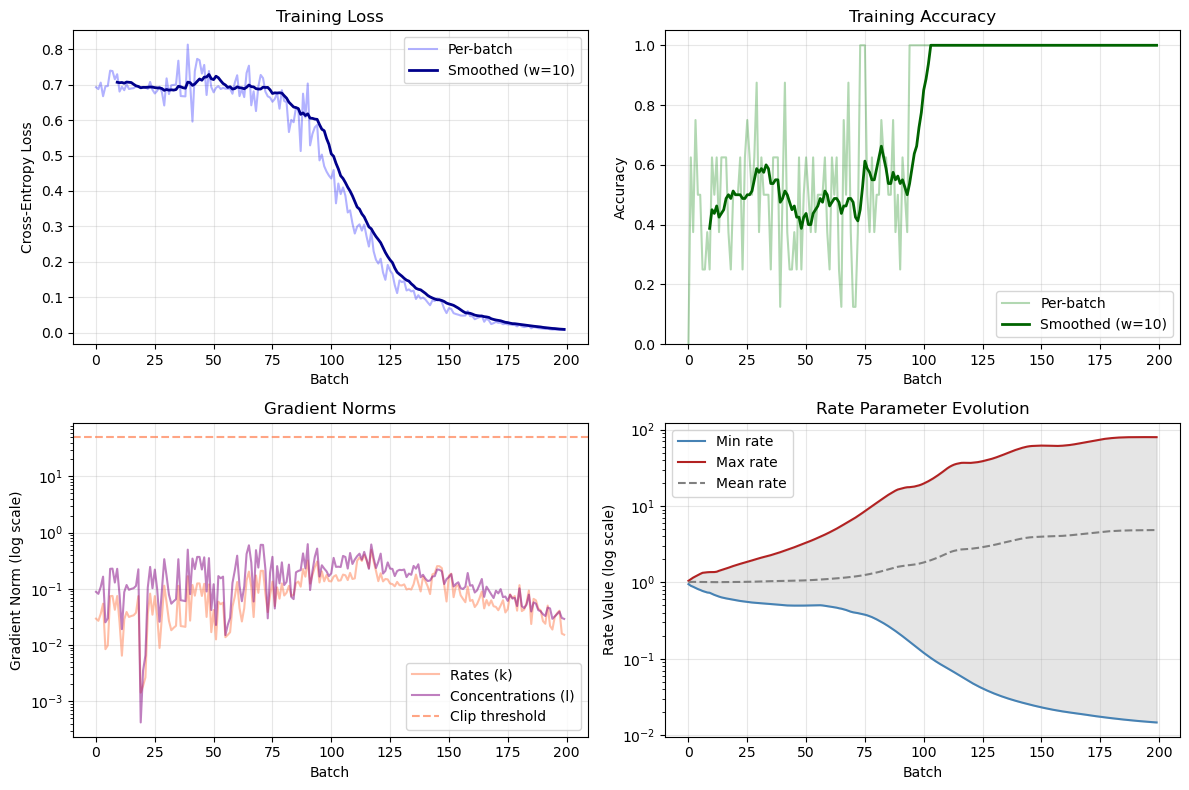

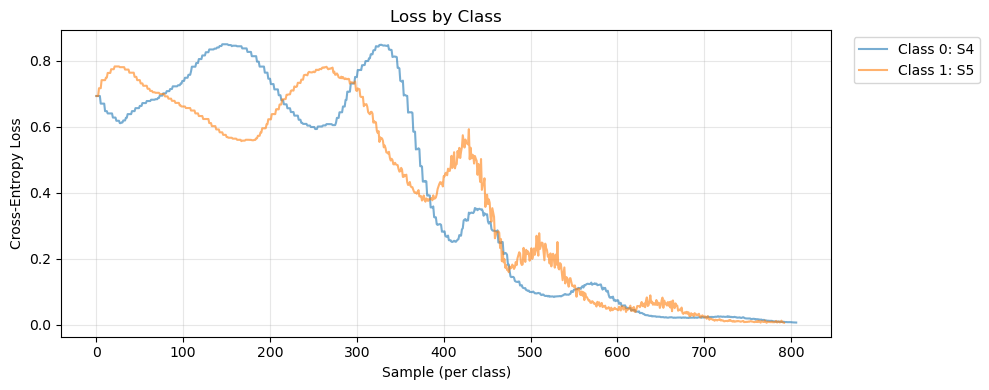

In [179]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 1. Raw loss over batches
ax1 = axes[0, 0]
ax1.plot(avg_loss_history, alpha=0.3, color='blue', label='Per-batch')
# Smoothed loss (rolling average)
window = 10
if len(avg_loss_history) >= window:
    smoothed_loss = np.convolve(avg_loss_history, np.ones(window)/window, mode='valid')
    ax1.plot(range(window-1, len(avg_loss_history)), smoothed_loss, color='darkblue', lw=2, label=f'Smoothed (w={window})')
ax1.set_xlabel('Batch')
ax1.set_ylabel('Cross-Entropy Loss')
ax1.set_title('Training Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Accuracy over batches
ax2 = axes[0, 1]
ax2.plot(accuracy_history, alpha=0.3, color='green', label='Per-batch')
if len(accuracy_history) >= window:
    smoothed_acc = np.convolve(accuracy_history, np.ones(window)/window, mode='valid')
    ax2.plot(range(window-1, len(accuracy_history)), smoothed_acc, color='darkgreen', lw=2, label=f'Smoothed (w={window})')
ax2.set_xlabel('Batch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training Accuracy')
ax2.set_ylim([0, 1.05])
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Gradient norms over time
ax3 = axes[1, 0]
grad_norms_k = [g[0] for g in grad_norm_history]
grad_norms_l = [g[1] for g in grad_norm_history]
ax3.semilogy(grad_norms_k, alpha=0.5, label='Rates (k)', color='coral')
ax3.semilogy(grad_norms_l, alpha=0.5, label='Concentrations (l)', color='purple')
ax3.axhline(y=max_grad_norm_k, color='coral', linestyle='--', alpha=0.7, label='Clip threshold')
ax3.set_xlabel('Batch')
ax3.set_ylabel('Gradient Norm (log scale)')
ax3.set_title('Gradient Norms')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Rate statistics over time
ax4 = axes[1, 1]
rate_mins = [r[0] for r in rate_stats_history]
rate_maxs = [r[1] for r in rate_stats_history]
rate_means = [r[2] for r in rate_stats_history]
ax4.semilogy(rate_mins, label='Min rate', color='steelblue')
ax4.semilogy(rate_maxs, label='Max rate', color='firebrick')
ax4.semilogy(rate_means, label='Mean rate', color='gray', linestyle='--')
ax4.fill_between(range(len(rate_mins)), rate_mins, rate_maxs, alpha=0.2, color='gray')
ax4.set_xlabel('Batch')
ax4.set_ylabel('Rate Value (log scale)')
ax4.set_title('Rate Parameter Evolution')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Per-class loss breakdown
fig2, ax = plt.subplots(figsize=(10, 4))
for i, losses in enumerate(loss_list):
    if losses:
        ax.plot(losses, alpha=0.6, label=f'Class {i}: {r_n.species_names[class_ids[i]]}')
ax.set_xlabel('Sample (per class)')
ax.set_ylabel('Cross-Entropy Loss')
ax.set_title('Loss by Class')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [161]:
n_l0 = 100
#l0_space = np.logspace(1, 4000, n_l0)
l0_space = np.linspace(1e-2, 60, n_l0)
prob_array = np.zeros((len(class_ids), n_l0))

t_span = (0, 10000)
num_points = 10000  
r_tol = 1e-6  
a_tol = 1e-6

r_n.update_rates(rates)

for (i, l0_t) in enumerate(l0_space):
    l0 = default_l0.copy()
    l0[:NR] = l0_t
        
    C_full = generate_positive_initial_concentrations_nnls(L, l0)
    _, C_reduced_init = sim.get_const_and_reduced_init(C_full)
    sim.make_reduced_rhs_with_conservation(l0)

    sol_reduced, C_reduced_final = sim.integrate(
        sim.reduced_ode_rhs, C_reduced_init, t_span=t_span,
        num_points=num_points, method='LSODA', rtol=r_tol, atol=a_tol)

    C_full = sim.recover_eliminated_species(l0, C_reduced_final)
    dC_dk = sim.dC_dk_func(C_reduced_final, l0, rates, dR_dC_func, dR_dk_func)
    dC_dk_full = sim.compute_dC_dk_full(dC_dk)

    probs, dprobs_dk_full, dprobs_dl_full = compute_normalized_gradients(C_full, dC_dk_full, dC_dl_full, class_ids)
    
    prob_array[:,i] = [probs[class_ids[k]] for k in range(len(class_ids))]


    

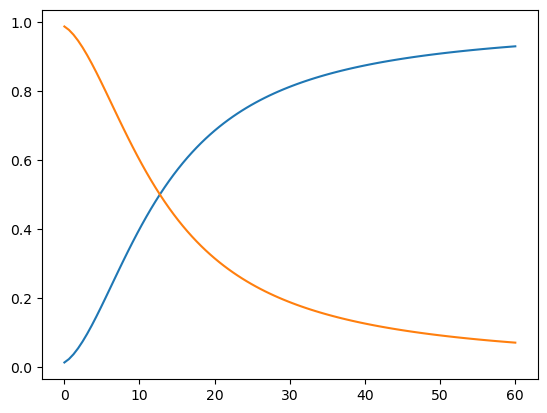

In [132]:
plt.plot(l0_space, prob_array[0,:])
plt.plot(l0_space, prob_array[1,:])

Completed row 10/20
Completed row 20/20
Grid evaluation complete!


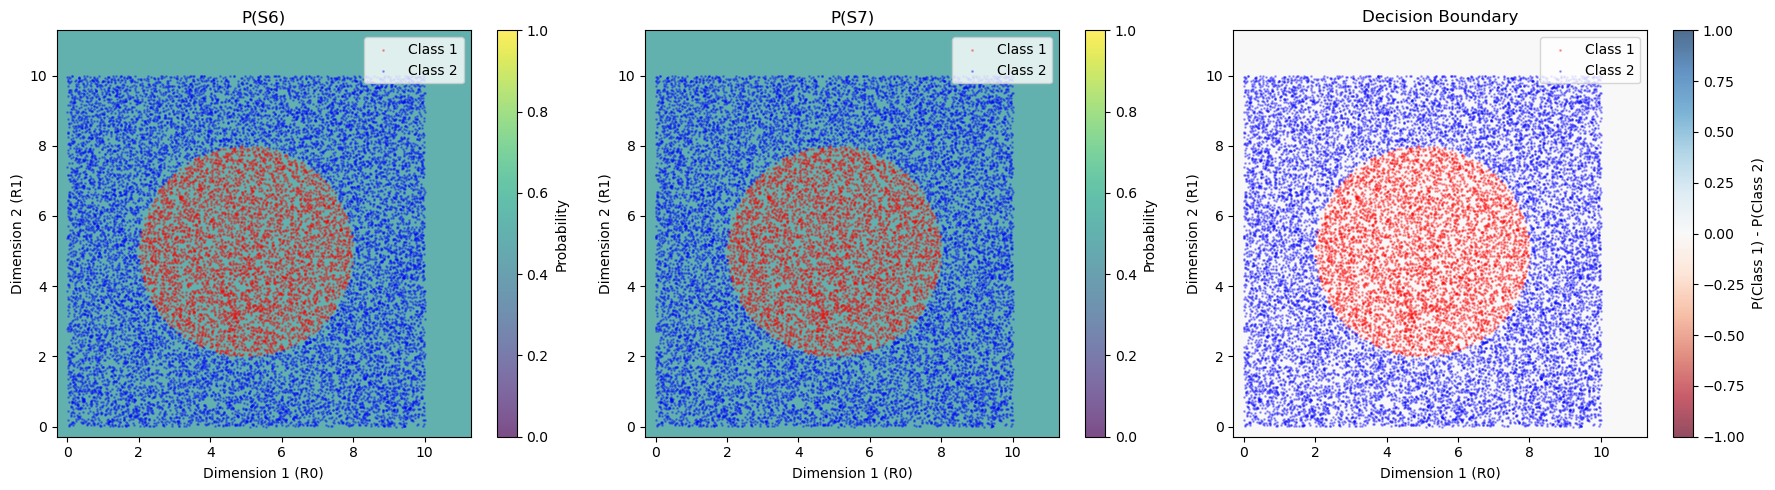

In [45]:
# Define 2D grid resolution
n_grid = 20  # grid points per dimension

# Get range from both distributions
all_data = np.vstack([dist_1, dist_2])
x_min, x_max = all_data[:, 0].min() * 0.9, all_data[:, 0].max() * 1.1
y_min, y_max = all_data[:, 1].min() * 0.9, all_data[:, 1].max() * 1.1

x_space = np.linspace(x_min, x_max, n_grid)
y_space = np.linspace(y_min, y_max, n_grid)
X_grid, Y_grid = np.meshgrid(x_space, y_space)

# prob_array now has shape (n_classes, n_grid, n_grid)
prob_array_2d = np.zeros((len(class_ids), n_grid, n_grid))


t_span = (0, 10000)
num_points = 10000  
r_tol = 1e-6  
a_tol = 1e-6

r_n.update_rates(rates)

for i in range(n_grid):
    for j in range(n_grid):
        l0 = default_l0.copy()
        l0[0] = X_grid[i, j]  # First receptor concentration
        l0[1] = Y_grid[i, j]  # Second receptor concentration
        
        C_full = generate_positive_initial_concentrations_nnls(L, l0)
        _, C_reduced_init = sim.get_const_and_reduced_init(C_full)
        sim.make_reduced_rhs_with_conservation(l0)

        sol_reduced, C_reduced_final = sim.integrate(
            sim.reduced_ode_rhs, C_reduced_init, t_span=t_span,
            num_points=num_points, method='LSODA', rtol=r_tol, atol=a_tol)

        C_full = sim.recover_eliminated_species(l0, C_reduced_final)
        dC_dk = sim.dC_dk_func(C_reduced_final, l0, rates, dR_dC_func, dR_dk_func)
        dC_dk_full = sim.compute_dC_dk_full(dC_dk)

        dC_dl = sim.dC_dl_func(C_reduced_final, l0, rates, dR_dC_func, dR_dl_func)
        dC_dl_full = sim.compute_dC_dk_full(dC_dl, l_bool=False)

        probs, dprobs_dk_full, dprobs_dl_full = compute_normalized_gradients(C_full, dC_dk_full, dC_dl_full, class_ids)
        
        for k in range(len(class_ids)):
            prob_array_2d[k, i, j] = probs[class_ids[k]]
    
    # Progress indicator
    if (i + 1) % 10 == 0:
        print(f"Completed row {i + 1}/{n_grid}")

print("Grid evaluation complete!")

# Plot heatmaps with scatter data overlay (3 panels)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot each class probability
for k in range(len(class_ids)):
    ax = axes[k]
    im = ax.pcolormesh(X_grid, Y_grid, prob_array_2d[k], cmap='viridis', alpha=0.7, shading='auto', vmin = 0, vmax = 1)
    plt.colorbar(im, ax=ax, label='Probability')
    
    # Overlay scatter data
    ax.scatter(dist_1[:, 0], dist_1[:, 1], alpha=0.3, s=1, c='red', label='Class 1')
    ax.scatter(dist_2[:, 0], dist_2[:, 1], alpha=0.3, s=1, c='blue', label='Class 2')
    
    ax.set_xlabel('Dimension 1 (R0)')
    ax.set_ylabel('Dimension 2 (R1)')
    ax.set_title(f'P({r_n.species_names[class_ids[k]]})')
    ax.legend(loc='upper right')

# Decision boundary (third panel)
ax = axes[2]
decision = prob_array_2d[0] - prob_array_2d[1]
im = ax.pcolormesh(X_grid, Y_grid, decision, cmap='RdBu', alpha=0.7, shading='auto', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, label='P(Class 1) - P(Class 2)')

# Decision boundary contour
ax.contour(X_grid, Y_grid, decision, levels=[0], colors='black', linewidths=2)

# Overlay scatter data
ax.scatter(dist_1[:, 0], dist_1[:, 1], alpha=0.3, s=1, c='red', label='Class 1')
ax.scatter(dist_2[:, 0], dist_2[:, 1], alpha=0.3, s=1, c='blue', label='Class 2')

ax.set_xlabel('Dimension 1 (R0)')
ax.set_ylabel('Dimension 2 (R1)')
ax.set_title('Decision Boundary')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

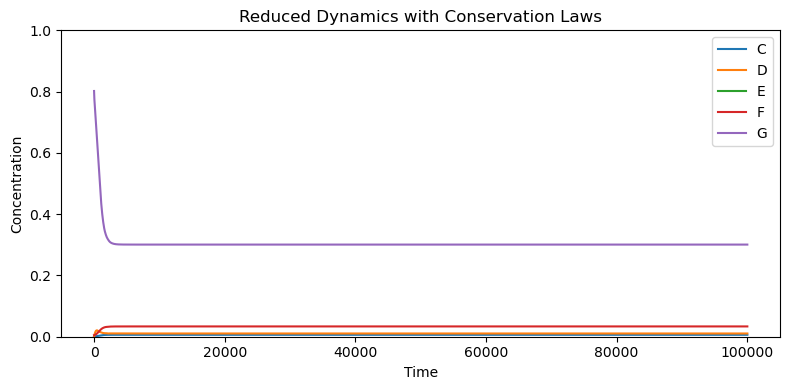

In [27]:
plt.figure(figsize=(8, 4))
for i, name in enumerate(sim.remaining_species):
    plt.plot(sol_reduced.t, sol_reduced.y[i], label=name)
plt.xlabel('Time')
plt.ylabel('Concentration')
plt.legend()
plt.ylim(0, 1)
plt.title('Reduced Dynamics with Conservation Laws')
plt.tight_layout()
plt.show()

In [60]:
def normalize(vec, norm):
    return vec / norm
    
def compute_normalized_gradients(C_full, dC_dk_full, dC_dl_full, class_ids):
    outputs = [C_full[class_ids[i]] for i in range(len(class_ids))]
    output_grads = [dC_dk_full[class_ids[i]] for i in range(len(class_ids))]
    output_grads_dl = [dC_dl_full[class_ids[i]] for i in range(len(class_ids))]
    norm = np.sum(outputs)
    probs = normalize(C_full, norm)
    dprobs_dk = dC_dk_full / norm - np.outer(np.array(C_full), np.array(np.sum(output_grads, axis = 0)) / norm**2)
    dprobs_dl = dC_dl_full / norm - np.outer(np.array(C_full), np.array(np.sum(output_grads_dl, axis = 0)) / norm**2)
    return probs, dprobs_dk, dprobs_dl

E_range = 1.0
B_range = 1.0
F_range = 1.0
C0 = 1
beta = 1
rates = generate_thermodynamic_rates(r_n, C0, beta, E_range, B_range, F_range)

#rates_orig = np.array([r_n.reactions[r_idx][2] for r_idx in range(len(r_n.reactions))])
#rates = np.array(rates_orig.copy())
#rates = 5*np.ones_like(rates_orig)
log_rates = np.log(rates)
r_n.update_rates(rates)
n_rates = len(rates)

t_span = (0, 100000)
num_points = 10000  
r_tol = 1e-12    
a_tol = 1e-12

eta_k = 4e0
eta_l = 1e0

class_ids = target_node_idxs
print([r_n.species_names[target_node_idx] for target_node_idx in target_node_idxs])
l_ind = NR+NS-1

default_l0 = np.ones(NR+NS)
log_l0 = np.log(default_l0)
l0_range = [NR, (NR+NS)-len(class_ids)]

loss_list = [[] for _ in range(len(class_ids))]
start_time = time.time()
batch_size = 2
num_batches = 5000 // batch_size  # total number of batches

for batch in range(num_batches):
    grad_accum_k = 0.0  # or np.zeros_like(rates) if grad is an array
    grad_accum_l = 0.0  # or np.zeros_like(rates) if grad is an array
    for _ in range(batch_size):
        class_number = random.randrange(n_classes)
        inputs = input_data.get_next_training_sample(class_number)
        l0 = default_l0.copy()
        l0[:NR] = inputs

        C_full = generate_positive_initial_concentrations_nnls(L, l0)
        _, C_reduced_init = sim.get_const_and_reduced_init(C_full)
        sim.make_reduced_rhs_with_conservation(l0)

        sol_reduced, C_reduced_final = sim.integrate(
            sim.reduced_ode_rhs, C_reduced_init, t_span=t_span,
            num_points=num_points, method='LSODA', rtol=r_tol, atol=a_tol
        )

        C_full = sim.recover_eliminated_species(l0, C_reduced_final)
        dC_dk = sim.dC_dk_func(C_reduced_final, l0, rates, dR_dC_func, dR_dk_func)
        dC_dk_full = sim.compute_dC_dk_full(dC_dk)

        dC_dl = sim.dC_dl_func(C_reduced_final, l0, rates, dR_dC_func, dR_dl_func)
        dC_dl_full = sim.compute_dC_dk_full(dC_dl, l_bool = False)

        probs, dprobs_dk_full, dprobs_dl_full = compute_normalized_gradients(C_full, dC_dk_full, dC_dl_full, class_ids)

        loss = (probs[class_ids[class_number]] - 1.0)
        grad_k = dprobs_dk_full[class_ids[class_number]] * loss
        grad_l = dprobs_dl_full[class_ids[class_number]] * loss
        grad_accum_k += grad_k
        grad_accum_l += grad_l
        loss_list[class_number].append(loss**2)

    grad_accum_k /= batch_size  # average the gradients
    grad_accum_l /= batch_size  # average the gradients
    log_rates = log_rates - eta_k * grad_accum_k * rates  # chain rule
    log_l0 = log_l0 - eta_l * grad_accum_l * l0

    rates = np.exp(log_rates)
    r_n.update_rates(rates)
    default_l0[l0_range[0]:l0_range[1]] = np.exp(log_l0[l0_range[0]:l0_range[1]])

end_time = time.time()
print(f"Time taken: {end_time - start_time} seconds")


['S3', 'S4']
Time taken: 135.96061086654663 seconds


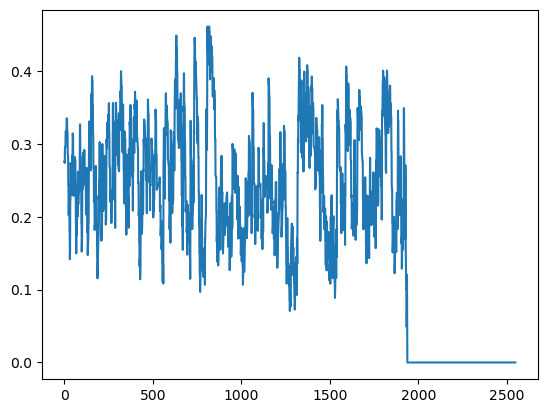

In [61]:
plt.plot(loss_list[0])

In [19]:
import numpy as np

def test_gradient_computations():
    """
    Unit test for gradient computations using finite differences.
    Tests both compute_normalized_gradients and compute_softmax_gradients.
    """
    np.random.seed(42)
    
    # ============== TEST SETUP ==============
    n_species = 5
    n_rates = 4
    n_l = 3
    class_ids = [2, 4]  # two output classes at species indices 2 and 4
    
    # Create random test data (all positive for concentrations)
    C_full = np.abs(np.random.randn(n_species)) + 0.5
    dC_dk_full = np.random.randn(n_species, n_rates)
    dC_dl_full = np.random.randn(n_species, n_l)
    
    eps_fd = 1e-6  # finite difference step size
    tol = 1e-5     # tolerance for comparison
    
    print("=" * 60)
    print("GRADIENT UNIT TESTS")
    print("=" * 60)
    
    # ============== TEST 1: NORMALIZED GRADIENTS ==============
    print("\n[TEST 1] compute_normalized_gradients")
    
    probs, dprobs_dk, dprobs_dl = compute_normalized_gradients(
        C_full, dC_dk_full, dC_dl_full, class_ids
    )
    
    # Test gradient w.r.t. C at class nodes using finite differences
    # We'll verify: dprobs_dk = dprobs/dC @ dC/dk
    # By checking dprobs/dC numerically
    
    print("\n  Testing dprobs/dC (normalized)...")
    dprobs_dC_numerical = np.zeros((n_species, n_species))
    
    for j in range(n_species):
        C_plus = C_full.copy()
        C_plus[j] += eps_fd
        probs_plus, _, _ = compute_normalized_gradients(C_plus, dC_dk_full, dC_dl_full, class_ids)
        
        C_minus = C_full.copy()
        C_minus[j] -= eps_fd
        probs_minus, _, _ = compute_normalized_gradients(C_minus, dC_dk_full, dC_dl_full, class_ids)
        
        dprobs_dC_numerical[:, j] = (probs_plus - probs_minus) / (2 * eps_fd)
    
    # Compute analytical dprobs/dC and compare
    # dprobs_dk = dprobs/dC @ dC/dk, so dprobs/dC @ dC/dk should match dprobs_dk
    dprobs_dk_reconstructed = dprobs_dC_numerical @ dC_dk_full
    
    # Only check at class nodes (other entries are not meaningful for classification)
    for i, idx in enumerate(class_ids):
        error_k = np.max(np.abs(dprobs_dk[idx] - dprobs_dk_reconstructed[idx]))
        status = "✓ PASS" if error_k < tol else "✗ FAIL"
        print(f"    Class {i} (species {idx}) dprobs_dk: max error = {error_k:.2e} {status}")
    
    # Test dprobs_dl similarly
    dprobs_dl_reconstructed = dprobs_dC_numerical @ dC_dl_full
    for i, idx in enumerate(class_ids):
        error_l = np.max(np.abs(dprobs_dl[idx] - dprobs_dl_reconstructed[idx]))
        status = "✓ PASS" if error_l < tol else "✗ FAIL"
        print(f"    Class {i} (species {idx}) dprobs_dl: max error = {error_l:.2e} {status}")
    
    # ============== TEST 2: SOFTMAX GRADIENTS ==============
    print("\n[TEST 2] compute_softmax_gradients")
    
    for temperature in [0.1, 1.0, 10.0]:
        print(f"\n  Temperature = {temperature}")
        
        probs_sm, dprobs_dk_sm, dprobs_dl_sm = compute_softmax_gradients(
            C_full, dC_dk_full, dC_dl_full, class_ids, temperature=temperature
        )
        
        # Numerical gradient of softmax w.r.t. C
        dprobs_dC_sm_numerical = np.zeros((n_species, n_species))
        
        for j in range(n_species):
            C_plus = C_full.copy()
            C_plus[j] += eps_fd
            probs_plus, _, _ = compute_softmax_gradients(C_plus, dC_dk_full, dC_dl_full, class_ids, temperature)
            
            C_minus = C_full.copy()
            C_minus[j] -= eps_fd
            probs_minus, _, _ = compute_softmax_gradients(C_minus, dC_dk_full, dC_dl_full, class_ids, temperature)
            
            dprobs_dC_sm_numerical[:, j] = (probs_plus - probs_minus) / (2 * eps_fd)
        
        dprobs_dk_sm_reconstructed = dprobs_dC_sm_numerical @ dC_dk_full
        dprobs_dl_sm_reconstructed = dprobs_dC_sm_numerical @ dC_dl_full
        
        for i, idx in enumerate(class_ids):
            error_k = np.max(np.abs(dprobs_dk_sm[idx] - dprobs_dk_sm_reconstructed[idx]))
            status = "✓ PASS" if error_k < tol else "✗ FAIL"
            print(f"    Class {i} (species {idx}) dprobs_dk: max error = {error_k:.2e} {status}")
        
        for i, idx in enumerate(class_ids):
            error_l = np.max(np.abs(dprobs_dl_sm[idx] - dprobs_dl_sm_reconstructed[idx]))
            status = "✓ PASS" if error_l < tol else "✗ FAIL"
            print(f"    Class {i} (species {idx}) dprobs_dl: max error = {error_l:.2e} {status}")
    
    # ============== TEST 3: LOSS GRADIENTS ==============
    print("\n[TEST 3] Loss gradient computation")
    
    # Use softmax probs for this test
    temperature = 1.0
    probs, dprobs_dk, dprobs_dl = compute_softmax_gradients(
        C_full, dC_dk_full, dC_dl_full, class_ids, temperature=temperature
    )
    
    target_class = 0
    target_prob = probs[class_ids[target_class]]
    p_vec = np.array([probs[class_ids[i]] for i in range(len(class_ids))])
    dpdk_vec = np.array([dprobs_dk[class_ids[i]] for i in range(len(class_ids))])
    
    target_vec = np.zeros(len(class_ids))
    target_vec[target_class] = 1.0
    
    # Cross-entropy gradient
    eps = 1e-8
    grad_k_ce = -dprobs_dk[class_ids[target_class]] / (target_prob + eps)
    
    # Numerical cross-entropy gradient w.r.t. k (via C)
    def cross_entropy_loss(C):
        p, _, _ = compute_softmax_gradients(C, dC_dk_full, dC_dl_full, class_ids, temperature)
        return -np.log(p[class_ids[target_class]] + eps)
    
    dL_dC_numerical = np.zeros(n_species)
    for j in range(n_species):
        C_plus = C_full.copy()
        C_plus[j] += eps_fd
        C_minus = C_full.copy()
        C_minus[j] -= eps_fd
        dL_dC_numerical[j] = (cross_entropy_loss(C_plus) - cross_entropy_loss(C_minus)) / (2 * eps_fd)
    
    grad_k_ce_reconstructed = dL_dC_numerical @ dC_dk_full
    error_ce = np.max(np.abs(grad_k_ce - grad_k_ce_reconstructed))
    status = "✓ PASS" if error_ce < tol else "✗ FAIL"
    print(f"\n  Cross-entropy grad_k: max error = {error_ce:.2e} {status}")
    
    # MSE gradient
    grad_k_mse = np.sum((p_vec - target_vec)[:, None] * dpdk_vec, axis=0)
    
    def mse_loss(C):
        p, _, _ = compute_softmax_gradients(C, dC_dk_full, dC_dl_full, class_ids, temperature)
        p_v = np.array([p[class_ids[i]] for i in range(len(class_ids))])
        return 0.5 * np.sum((p_v - target_vec) ** 2)
    
    dL_dC_mse_numerical = np.zeros(n_species)
    for j in range(n_species):
        C_plus = C_full.copy()
        C_plus[j] += eps_fd
        C_minus = C_full.copy()
        C_minus[j] -= eps_fd
        dL_dC_mse_numerical[j] = (mse_loss(C_plus) - mse_loss(C_minus)) / (2 * eps_fd)
    
    grad_k_mse_reconstructed = dL_dC_mse_numerical @ dC_dk_full
    error_mse = np.max(np.abs(grad_k_mse - grad_k_mse_reconstructed))
    status = "✓ PASS" if error_mse < tol else "✗ FAIL"
    print(f"  MSE grad_k: max error = {error_mse:.2e} {status}")
    
    # ============== TEST 4: PROBABILITY SANITY CHECKS ==============
    print("\n[TEST 4] Probability sanity checks")
    
    # Normalized: class probs should sum to 1
    probs_norm, _, _ = compute_normalized_gradients(C_full, dC_dk_full, dC_dl_full, class_ids)
    class_probs_norm = [probs_norm[idx] for idx in class_ids]
    sum_norm = sum(class_probs_norm)
    status = "✓ PASS" if abs(sum_norm - 1.0) < 1e-10 else "✗ FAIL"
    print(f"  Normalized probs sum to 1: {sum_norm:.10f} {status}")
    
    # Softmax: class probs should sum to 1
    probs_sm, _, _ = compute_softmax_gradients(C_full, dC_dk_full, dC_dl_full, class_ids, temperature=1.0)
    class_probs_sm = [probs_sm[idx] for idx in class_ids]
    sum_sm = sum(class_probs_sm)
    status = "✓ PASS" if abs(sum_sm - 1.0) < 1e-10 else "✗ FAIL"
    print(f"  Softmax probs sum to 1: {sum_sm:.10f} {status}")
    
    # All probs should be positive
    all_positive_norm = all(p >= 0 for p in class_probs_norm)
    all_positive_sm = all(p >= 0 for p in class_probs_sm)
    status = "✓ PASS" if all_positive_norm and all_positive_sm else "✗ FAIL"
    print(f"  All probs non-negative: {status}")
    
    print("\n" + "=" * 60)
    print("TESTS COMPLETE")
    print("=" * 60)

# Run the tests
test_gradient_computations()

GRADIENT UNIT TESTS

[TEST 1] compute_normalized_gradients

  Testing dprobs/dC (normalized)...
    Class 0 (species 2) dprobs_dk: max error = 6.57e-11 ✓ PASS
    Class 1 (species 4) dprobs_dk: max error = 1.42e-11 ✓ PASS
    Class 0 (species 2) dprobs_dl: max error = 3.12e-11 ✓ PASS
    Class 1 (species 4) dprobs_dl: max error = 3.19e-11 ✓ PASS

[TEST 2] compute_softmax_gradients

  Temperature = 0.1
    Class 0 (species 2) dprobs_dk: max error = 1.49e-10 ✓ PASS
    Class 1 (species 4) dprobs_dk: max error = 3.14e-11 ✓ PASS
    Class 0 (species 2) dprobs_dl: max error = 7.01e-11 ✓ PASS
    Class 1 (species 4) dprobs_dl: max error = 2.39e-11 ✓ PASS

  Temperature = 1.0
    Class 0 (species 2) dprobs_dk: max error = 4.76e-12 ✓ PASS
    Class 1 (species 4) dprobs_dk: max error = 5.74e-11 ✓ PASS
    Class 0 (species 2) dprobs_dl: max error = 1.01e-11 ✓ PASS
    Class 1 (species 4) dprobs_dl: max error = 4.07e-11 ✓ PASS

  Temperature = 10.0
    Class 0 (species 2) dprobs_dk: max error = 1

In [21]:
import numpy as np
import time

def test_sensitivity_gradients():
    """
    Unit test for dC/dk and dC/dl gradients using finite differences.
    Compares analytical sensitivities from the ODE solver against numerical finite differences.
    """
    print("=" * 70)
    print("SENSITIVITY GRADIENT TESTS (dC/dk and dC/dl)")
    print("=" * 70)
    
    eps_fd = 1e-5  # finite difference step size
    tol = 1e-4     # tolerance (looser because ODE integration has numerical error)
    
    # ============== SETUP: Get baseline solution ==============
    # Use current rates and a fixed input
    test_class = 0
    inputs = input_data.get_next_training_sample(test_class)
    l0 = default_l0.copy()
    l0[:NR] = inputs
    
    # Baseline forward pass
    C_full_base = generate_positive_initial_concentrations_nnls(L, l0)
    _, C_reduced_init = sim.get_const_and_reduced_init(C_full_base)
    sim.make_reduced_rhs_with_conservation(l0)
    
    sol_reduced, C_reduced_base = sim.integrate(
        sim.reduced_ode_rhs, C_reduced_init, t_span=t_span,
        num_points=num_points, method='LSODA', rtol=r_tol, atol=a_tol
    )
    
    C_full_base = sim.recover_eliminated_species(l0, C_reduced_base)
    
    # Analytical gradients
    dC_dk_analytical = sim.dC_dk_func(C_reduced_base, l0, rates, dR_dC_func, dR_dk_func)
    dC_dk_full_analytical = sim.compute_dC_dk_full(dC_dk_analytical)
    
    dC_dl_analytical = sim.dC_dl_func(C_reduced_base, l0, rates, dR_dC_func, dR_dl_func)
    dC_dl_full_analytical = sim.compute_dC_dk_full(dC_dl_analytical, l_bool=True)
    
    print(f"\nBaseline concentrations: {C_full_base}")
    print(f"Rates shape: {rates.shape}, dC_dk shape: {dC_dk_full_analytical.shape}")
    print(f"l0 shape: {l0.shape}, dC_dl shape: {dC_dl_full_analytical.shape}")
    
    # ============== TEST 1: dC/dk via finite differences ==============
    print("\n[TEST 1] dC/dk - Gradient w.r.t. rate constants")
    
    n_rates_to_test = min(5, len(rates))  # test first few rates (full test is slow)
    
    dC_dk_numerical = np.zeros_like(dC_dk_full_analytical)
    
    for k_idx in range(n_rates_to_test):
        # Perturb rate k_idx positively
        rates_plus = rates.copy()
        rates_plus[k_idx] += eps_fd
        r_n.update_rates(rates_plus)
        
        C_full_plus = generate_positive_initial_concentrations_nnls(L, l0)
        _, C_reduced_init_plus = sim.get_const_and_reduced_init(C_full_plus)
        sim.make_reduced_rhs_with_conservation(l0)
        _, C_reduced_plus = sim.integrate(
            sim.reduced_ode_rhs, C_reduced_init_plus, t_span=t_span,
            num_points=num_points, method='LSODA', rtol=r_tol, atol=a_tol
        )
        C_full_plus = sim.recover_eliminated_species(l0, C_reduced_plus)
        
        # Perturb rate k_idx negatively
        rates_minus = rates.copy()
        rates_minus[k_idx] -= eps_fd
        r_n.update_rates(rates_minus)
        
        C_full_minus = generate_positive_initial_concentrations_nnls(L, l0)
        _, C_reduced_init_minus = sim.get_const_and_reduced_init(C_full_minus)
        sim.make_reduced_rhs_with_conservation(l0)
        _, C_reduced_minus = sim.integrate(
            sim.reduced_ode_rhs, C_reduced_init_minus, t_span=t_span,
            num_points=num_points, method='LSODA', rtol=r_tol, atol=a_tol
        )
        C_full_minus = sim.recover_eliminated_species(l0, C_reduced_minus)
        
        # Central difference
        dC_dk_numerical[:, k_idx] = (C_full_plus - C_full_minus) / (2 * eps_fd)
    
    # Restore original rates
    r_n.update_rates(rates)
    
    # Compare
    print(f"\n  Testing first {n_rates_to_test} rate gradients:")
    for k_idx in range(n_rates_to_test):
        analytical = dC_dk_full_analytical[:, k_idx]
        numerical = dC_dk_numerical[:, k_idx]
        
        # Relative error (avoid division by zero)
        denom = np.maximum(np.abs(analytical), np.abs(numerical)) + 1e-10
        rel_error = np.abs(analytical - numerical) / denom
        max_rel_error = np.max(rel_error)
        max_abs_error = np.max(np.abs(analytical - numerical))
        
        status = "✓ PASS" if max_rel_error < tol or max_abs_error < 1e-8 else "✗ FAIL"
        print(f"    Rate {k_idx}: max_rel_err={max_rel_error:.2e}, max_abs_err={max_abs_error:.2e} {status}")
        
        if status == "✗ FAIL":
            print(f"      Analytical: {analytical}")
            print(f"      Numerical:  {numerical}")
    
    # ============== TEST 2: dC/dl via finite differences ==============
    print("\n[TEST 2] dC/dl - Gradient w.r.t. initial conditions (l0)")
    
    n_l_to_test = min(5, len(l0))  # test first few l0 entries
    
    dC_dl_numerical = np.zeros_like(dC_dl_full_analytical)
    
    for l_idx in range(n_l_to_test):
        # Perturb l0[l_idx] positively
        l0_plus = l0.copy()
        l0_plus[l_idx] += eps_fd
        
        r_n.update_rates(rates)  # ensure rates are correct
        C_full_plus = generate_positive_initial_concentrations_nnls(L, l0_plus)
        _, C_reduced_init_plus = sim.get_const_and_reduced_init(C_full_plus)
        sim.make_reduced_rhs_with_conservation(l0_plus)
        _, C_reduced_plus = sim.integrate(
            sim.reduced_ode_rhs, C_reduced_init_plus, t_span=t_span,
            num_points=num_points, method='LSODA', rtol=r_tol, atol=a_tol
        )
        C_full_plus = sim.recover_eliminated_species(l0_plus, C_reduced_plus)
        
        # Perturb l0[l_idx] negatively
        l0_minus = l0.copy()
        l0_minus[l_idx] -= eps_fd
        
        C_full_minus = generate_positive_initial_concentrations_nnls(L, l0_minus)
        _, C_reduced_init_minus = sim.get_const_and_reduced_init(C_full_minus)
        sim.make_reduced_rhs_with_conservation(l0_minus)
        _, C_reduced_minus = sim.integrate(
            sim.reduced_ode_rhs, C_reduced_init_minus, t_span=t_span,
            num_points=num_points, method='LSODA', rtol=r_tol, atol=a_tol
        )
        C_full_minus = sim.recover_eliminated_species(l0_minus, C_reduced_minus)
        
        # Central difference
        dC_dl_numerical[:, l_idx] = (C_full_plus - C_full_minus) / (2 * eps_fd)
    
    # Compare
    print(f"\n  Testing first {n_l_to_test} l0 gradients:")
    for l_idx in range(n_l_to_test):
        analytical = dC_dl_full_analytical[:, l_idx]
        numerical = dC_dl_numerical[:, l_idx]
        
        denom = np.maximum(np.abs(analytical), np.abs(numerical)) + 1e-10
        rel_error = np.abs(analytical - numerical) / denom
        max_rel_error = np.max(rel_error)
        max_abs_error = np.max(np.abs(analytical - numerical))
        
        status = "✓ PASS" if max_rel_error < tol or max_abs_error < 1e-8 else "✗ FAIL"
        print(f"    l0[{l_idx}]: max_rel_err={max_rel_error:.2e}, max_abs_err={max_abs_error:.2e} {status}")
        
        if status == "✗ FAIL":
            print(f"      Analytical: {analytical}")
            print(f"      Numerical:  {numerical}")
    
    # ============== TEST 3: End-to-end gradient check ==============
    print("\n[TEST 3] End-to-end: dLoss/dk via finite differences")
    
    # Compute analytical loss gradient for cross-entropy
    probs, dprobs_dk_full, _ = compute_normalized_gradients(
        C_full_base, dC_dk_full_analytical, dC_dl_full_analytical, class_ids
    )
    target_prob = probs[class_ids[test_class]]
    grad_k_analytical = -dprobs_dk_full[class_ids[test_class]] / (target_prob + 1e-8)
    
    # Numerical loss gradient
    def compute_loss_for_rates(test_rates):
        r_n.update_rates(test_rates)
        C_init = generate_positive_initial_concentrations_nnls(L, l0)
        _, C_red_init = sim.get_const_and_reduced_init(C_init)
        sim.make_reduced_rhs_with_conservation(l0)
        _, C_red = sim.integrate(
            sim.reduced_ode_rhs, C_red_init, t_span=t_span,
            num_points=num_points, method='LSODA', rtol=r_tol, atol=a_tol
        )
        C = sim.recover_eliminated_species(l0, C_red)
        
        # Normalized probabilities
        outputs = [C[class_ids[i]] for i in range(len(class_ids))]
        norm = np.sum(outputs)
        p_target = C[class_ids[test_class]] / norm
        return -np.log(p_target + 1e-8)
    
    grad_k_numerical = np.zeros(n_rates_to_test)
    for k_idx in range(n_rates_to_test):
        rates_plus = rates.copy()
        rates_plus[k_idx] += eps_fd
        loss_plus = compute_loss_for_rates(rates_plus)
        
        rates_minus = rates.copy()
        rates_minus[k_idx] -= eps_fd
        loss_minus = compute_loss_for_rates(rates_minus)
        
        grad_k_numerical[k_idx] = (loss_plus - loss_minus) / (2 * eps_fd)
    
    # Restore rates
    r_n.update_rates(rates)
    
    print(f"\n  Testing first {n_rates_to_test} end-to-end loss gradients:")
    for k_idx in range(n_rates_to_test):
        analytical = grad_k_analytical[k_idx]
        numerical = grad_k_numerical[k_idx]
        
        denom = max(abs(analytical), abs(numerical)) + 1e-10
        rel_error = abs(analytical - numerical) / denom
        abs_error = abs(analytical - numerical)
        
        status = "✓ PASS" if rel_error < tol or abs_error < 1e-8 else "✗ FAIL"
        print(f"    dLoss/dk[{k_idx}]: analytical={analytical:.6e}, numerical={numerical:.6e}, "
              f"rel_err={rel_error:.2e} {status}")
    
    print("\n" + "=" * 70)
    print("SENSITIVITY TESTS COMPLETE")
    print("=" * 70)

# Run the test
test_sensitivity_gradients()

SENSITIVITY GRADIENT TESTS (dC/dk and dC/dl)

Baseline concentrations: [7.47986594e+01 7.52140828e+01 5.02455597e-01 5.60047931e-01
 5.02455597e-01 5.60047931e-01 5.02455597e-01 5.60047931e-01
 8.12617232e-02 9.18738277e-01 4.79666328e-02 9.52033367e-01]
Rates shape: (34,), dC_dk shape: (12, 34)
l0 shape: (7,), dC_dl shape: (12, 7)

[TEST 1] dC/dk - Gradient w.r.t. rate constants

  Testing first 5 rate gradients:
    Rate 0: max_rel_err=5.26e-02, max_abs_err=5.55e-12 ✓ PASS
    Rate 1: max_rel_err=3.50e-09, max_abs_err=1.76e-12 ✓ PASS
    Rate 2: max_rel_err=5.26e-02, max_abs_err=5.55e-12 ✓ PASS
    Rate 3: max_rel_err=3.50e-09, max_abs_err=1.76e-12 ✓ PASS
    Rate 4: max_rel_err=5.26e-02, max_abs_err=5.55e-12 ✓ PASS

[TEST 2] dC/dl - Gradient w.r.t. initial conditions (l0)

  Testing first 5 l0 gradients:
    l0[0]: max_rel_err=8.71e-05, max_abs_err=3.17e-10 ✓ PASS
    l0[1]: max_rel_err=5.29e-05, max_abs_err=3.17e-10 ✓ PASS
    l0[2]: max_rel_err=1.54e-09, max_abs_err=3.53e-12 ✓ PAS